# General analysis of "true" (simulated by VASP using DFT) trajectories

We study a "Hybrid perovskite" material: two connected SnI6 "inorganic" plus short N-C-C-C-C-N "organic" chains (see Vesta for structure).

Note that Sn has configuration 5s2 5p2, but loses outermost electron pair, hence being able to form six bonds.

*Note on the dataset used*: we use a 10 000 steps VASP simulation (NVT at 300 K). The exact files used can be deduced by looking at the following four notebook cells.

## Environment setup

In [1]:
!pwd 

/home/libero/LCPB_2026/Project


In [ ]:
# the three following cells to set paths once and for all:

In [2]:
%env OUTCAR_FILE=./new_data/1.NVT_300/A.1_10K/OUTCAR # already unzipped folder (one line from terminal)

env: OUTCAR_FILE=./new_data/1.NVT_300/A.1_10K/OUTCAR # already unzipped folder (one line from terminal)


In [3]:
%env INCAR_FILE=./new_data/1.NVT_300/A.1_10K/INCAR

env: INCAR_FILE=./new_data/1.NVT_300/A.1_10K/INCAR


In [4]:
outcar_file="./new_data/1.NVT_300/A.1_10K/OUTCAR"
incar_file="./new_data/1.NVT_300/A.1_10K/INCAR"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.io import iread
from ase.geometry.rdf import get_rdf
from ase.neighborlist import neighbor_list
from ase.geometry import find_mic
import ase.units as units
from ase.units import fs, kB
import os

import pickle

from useful_functions import clean_dataset # custom functions

In [ ]:
from pymbar import timeseries

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



## Visualize simulation cell

In [ ]:
atoms= read(outcar_file)

In [9]:
cell_vectors=atoms.get_cell()
print("Vectors defining cell:", cell_vectors)

Vectors defining cell: Cell([[8.742892963, 0.0, -0.031376383], [0.0, 8.422714245, 0.0], [-3.957950916, 0.0, 20.036876932]])


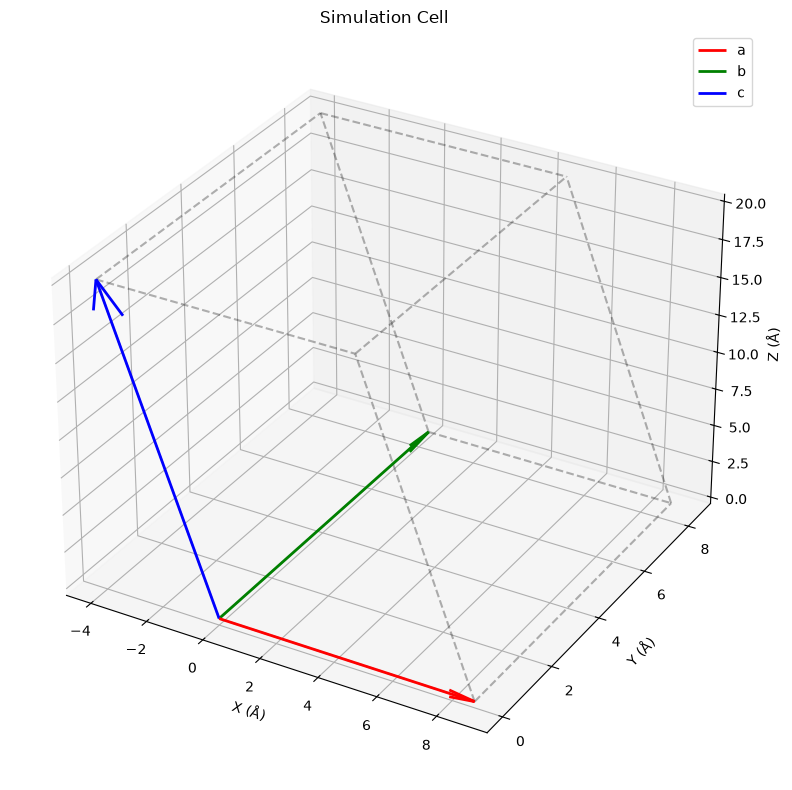

Cell lengths: |a|=8.74, |b|=8.42, |c|=20.42 Å
Volume: 1474.45 Å³


In [10]:
cell = np.array(cell_vectors)

a, b, c = cell
origin = np.zeros(3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw vectors
for vec, color, label in zip([a, b, c], ['r', 'g', 'b'], ['a', 'b', 'c']):
    ax.quiver(*origin, *vec, color=color, arrow_length_ratio=0.1, linewidth=2, label=label)

# Draw cell edges
corners = np.array([
    origin,
    a, b, c,
    a+b, a+c, b+c,
    a+b+c
])

edges = [
    (0,1), (0,2), (0,3),  # from origin
    (1,4), (1,5),  # from a
    (2,4), (2,6),  # from b
    (3,5), (3,6),  # from c
    (4,7), (5,7), (6,7)   # to opposite corner
]

for i, j in edges:
    ax.plot(*zip(corners[i], corners[j]), 'k--', alpha=0.3)

ax.set_xlabel('X (Å)')
ax.set_ylabel('Y (Å)')
ax.set_zlabel('Z (Å)')
ax.legend()
ax.set_title('Simulation Cell')
plt.tight_layout()
plt.show()

print(f"Cell lengths: |a|={np.linalg.norm(a):.2f}, |b|={np.linalg.norm(b):.2f}, |c|={np.linalg.norm(c):.2f} Å")
print(f"Volume: {np.abs(np.dot(a, np.cross(b, c))):.2f} Å³")

Note: the box is the "unit cell" of the simulation - there's exactly one in the calculation.

3x3x3=27 cells are repeated in space, and interactions must be accounted for considering the closest n atoms (or all atoms within a certain distance) in neighboring cells also.

VASP is (almost) exact as it uses DFT; distance cutoffs (not strictly "interaction" cutoffs) are applied in limited circumstances:

In [15]:
! grep "cutoff" $OUTCAR_FILE | sort -u

grep: #: No such file or directory
grep: already: No such file or directory
grep: unzipped: No such file or directory
grep: folder: No such file or directory
grep: (one: No such file or directory
grep: line: No such file or directory
grep: from: No such file or directory
grep: terminal): No such file or directory
./new_data/1.NVT_300/A.1_10K/OUTCAR:   ENAUG  =  644.9 eV  augmentation charge cutoff
./new_data/1.NVT_300/A.1_10K/OUTCAR:   ENINI  =  400.0     initial cutoff
./new_data/1.NVT_300/A.1_10K/OUTCAR:   NGX,Y,Z   is equivalent  to a cutoff of  11.41, 11.05, 11.40 a.u.
./new_data/1.NVT_300/A.1_10K/OUTCAR:   NGXF,Y,Z  is equivalent  to a cutoff of  22.82, 22.11, 22.79 a.u.
./new_data/1.NVT_300/A.1_10K/OUTCAR:   RCLOC  =    0.701    cutoff for local pot                                                        
./new_data/1.NVT_300/A.1_10K/OUTCAR:   RCORE  =    1.100    outmost cutoff radius                                                       
./new_data/1.NVT_300/A.1_10K/OUTCAR:   RC

In [17]:
my_full_file="./new_data/1.NVT_300/A.1_10K/cleaned_dataset.extxyz" 

In [18]:
# in case not already existing:
clean_dataset(
    outcar_file=outcar_file,
    destination_file=my_full_file,
    start_idx=0
)

Retrieved 10000 structures from OUTCAR.
File saved as ./new_data/1.NVT_300/A.1_10K/cleaned_dataset.extxyz


0

In [19]:
! ls -lhS $(dirname $OUTCAR_FILE) # biggest first

.:
total 23M
-rw-r--r-- 1 libero libero 5.0M Aug 14 13:30 general_analysis_updated_2.ipynb
-rw-r--r-- 1 libero libero 5.0M Aug 14 11:54 general_analysis_updated_1.ipynb
-rw-r--r-- 1 libero libero 5.0M Aug  8 18:33 general_analysis_updated.ipynb
-rw-r--r-- 1 libero libero 4.3M Aug  4 12:53 General_analysisi.ipynb
-rw-r--r-- 1 libero libero 1.9M Aug  4 12:53 SOAPTrajectories_par.ipynb
-rw-r--r-- 1 libero libero 831K Aug  8 17:23 element_dynamics_comparison.png
-rw-r--r-- 1 libero libero 665K Aug  8 17:19 trajectory_dynamics_comparison.png
-rw-r--r-- 1 libero libero 218K Aug  8 18:08 temperature_profile.png
-rw-r--r-- 1 libero libero 206K Aug  9 00:38 training_mace_updated.ipynb
-rw-r--r-- 1 libero libero  16K Aug  7 13:06 basic_exploration.ipynb
drwxr-xr-x 2 libero libero 4.0K Aug  4 12:53 Data
drwxr-xr-x 2 libero libero 4.0K Aug 14 15:37 __pycache__
drwxr-xr-x 2 libero libero 4.0K Aug  4 13:00 compressed_data
drwxr-xr-x 2 libero libero 4.0K Aug  7 12:11 compressed_new_data
drwxr-xr-x 2 

In [68]:
output_dir = "./new_data/1.NVT_300/A.1_10K/general_analysis_results/"
os.makedirs(output_dir, exist_ok=True)

In [83]:
images = read(my_full_file, index=':')

In [21]:
print("Total images:", len(images))

Total images: 10000


## RDF-based analysis -- full data

The Radial Distribution Function, usually denoted as $g(r)$, is a fundamental structural tool used in physics and materials science to describe how atoms are spatially packed around one another.

Imagine choosing one specific atom in your system as a "central reference atom." You then draw a series of thin, concentric spherical shells of radius r and thickness Δr around it. The RDF measures the local *atomic* density within these shells compared to the overall average density of the system.

RDF plot will have highly distinct, recognizable features:

    Sharp, Discrete Peaks: Crystals possess highly periodic, long-range structural order. Because atoms sit at fixed positions, they only exist at very specific distances from each other. RDF will show sharp "spikes" or peaks at those precise geometric distances, corresponding to the 1st nearest neighbors, 2nd nearest neighbors, and so on.

    Zero-Probability Gaps: Between these peaks, g(r) will drop exactly to 0, because the rigid crystal structure dictates that no atoms can physically exist in the spaces between the designated lattice sites.

    Long-Range Order: Unlike liquids or amorphous materials, where the peaks quickly smooth out and flatten to a value of 1.0 at long distances, a perfect crystal will continue to display sharp peaks even at very large values of r.



We compute other quantities:

1. Integrated Coordination Number ($N_c$)

The standard Radial Distribution Function $g(r)$ tells you the relative probability of finding atoms at a distance $r$, but it does not directly count them. The Integrated Coordination Number solves this by summing up the actual number of atoms.Mathematically, it is defined as:$$N_c(R) = 4\pi \rho \int_0^R r^2 g(r) dr$$

Where $\rho$ is the total number density of the crystal (total atoms divided by cell volume).

2. Potential of Mean Force (PMF )  [mu = Joule]

The Potential of Mean Force denoted as $W(r)$, is a thermodynamic quantity that translates structural probabilities into an energy landscape. It is derived directly from the fluid/solid structure using the Boltzmann inversion:$$W(r) = -k_B T \ln [g(r)]$$Where $k_B$ is the Boltzmann constant and $T$ is the simulation temperature.

Physical Meaning for the Whole Crystal

Free Energy Landscape: $W(r)$ represents the effective free energy profile of the system as a function of interatomic distance. It accounts not just for the direct electrostatic and Van der Waals forces between two specific atoms, but also for the "mean" average influence exerted by all the surrounding atoms in the crystal matrix.

Interpreting the Minima: Every peak in total $g(r)$ becomes a local energy minimum (a well) in $W(r)$. The deepest wells correspond to the most stable chemical bonds in the system . The curvature at the bottom of these wells tells you about bond stiffness: a narrow, sharp well means a rigid, highly stable bond, while a broad well implies a soft, flexible interaction that allows for large thermal vibrations.

3. Rolling Window Peak Tracking ($g_{max}$ and FWHM)

Unlike the first two quantities which are averaged over the entire simulation, this is a kinetic and temporal diagnostic. It splits the trajectory into small chronological segments (windows) and extracts two critical shape features from the highest peak of the $g(r)$:

- $g_{max}$ (Peak Height): The absolute maximum value of the primary peak in that specific time window.

- FWHM (Full Width at Half Maximum): The width of the peak measured at exactly half of its maximum height.

Physical Meaning for the Whole Crystal

Tracking Crystallinity ($g_{max}$): The height of an RDF peak reflects structural order. If material is highly crystalline and well-ordered, atoms sit precisely at fixed distances, making the peaks incredibly tall. If $g_{max}$ rises during the simulation, your crystal is ordering itself. If it drops significantly, it means the structure is becoming disordered, amorphized, or undergoing a structural transition.

Tracking Thermal Fluctuations (FWHM): The width of the peak is a measure of atomic displacement and thermal shaking. A broadening peak (higher FWHM) means atoms are vibrating more violently around their equilibrium positions, which typically happens if the temperature spikes or if the structural framework is softening.

The Ultimate Equilibrium Test: When plotting these two metrics against time, they should ideally converge into flat, horizontal lines. The exact frame where $g_{max}$ and FWHM stop drifting and stabilize into a steady state marks the exact moment your simulation reached true thermodynamic equilibrium.

In [ ]:
rmax = 3.9 # maximum distance for RDF (angstrom) ---> ok bc max possible with current cell dimension (error otherwise)

In [23]:
nbins = 1000

all_rdfs = []
distances = None


for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins) # RDF for EACH individual atom, averaged over all atoms...
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0) # ...averaged over time steps


number of RDF values: 1000


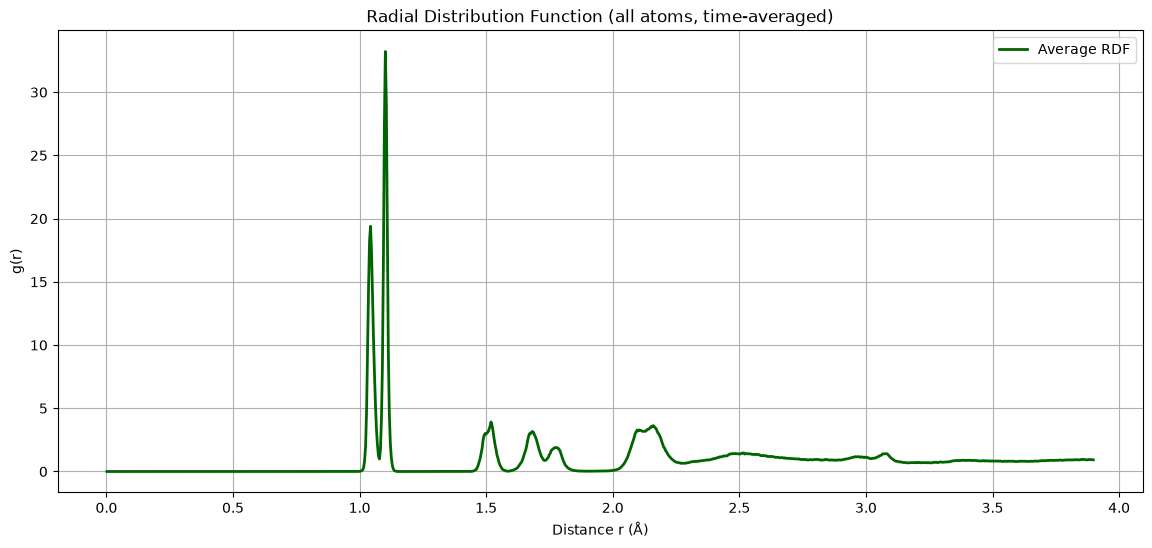

In [24]:
print("number of RDF values:", len(rdf_values))


plt.figure(figsize=(14,6))
plt.plot(distances, avg_rdf, color='darkgreen', lw=2, label='Average RDF')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function (all atoms, time-averaged)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
all_atoms_rdf = {
    "distances": distances,
    "all_rdfs": all_rdfs,
    "avg_rdf": avg_rdf,
}

pickle_path = os.path.join(output_dir, "all_atoms_rdf.pickle")

with open(pickle_path, "wb") as f:
    pickle.dump(all_atoms_rdf, f)

1 A
Extremely sharp, intense peak corresponds to the C-H and N-H covalent bonds within your organic cations.
Because Hydrogen is highly abundant in the organic part and these covalent bonds are incredibly rigid with very little distance variation, they create a massive, highly localized probability spike.

1.5 A
This peak corresponds precisely to the C-N covalent bonds inside the organic molecules.
Physical Meaning: It is completely separated from the hydrogen peaks, showing that the organic molecules maintain their molecular integrity throughout your entire time series.

2.5 - 3.8 A
Sn-I Bonds (3.1−3.2 A˚): The main component of this broad mountain is the coordination bond between Tin and Iodine, forming the corners of the SnI6​ octahedra.
Hydrogen Bonding (2.5−3.0 A˚): The leading edge of this broad feature captures the weak hydrogen interactions (N-H…I and C-H…I) where the organic molecules "anchor" themselves to the inorganic cage.
Intermolecular Organic Distances: Non-bonded distances between different parts of the organic cations also contribute to the background noise here.


The Sharp Peaks (<2.0 A˚): Covalent intramolecular bonds are very strong. Even at room temperature, the atoms do not vibrate far from their equilibrium positions, keeping the peaks narrow.

The Broad Peaks (>2.5 A˚): The inorganic lattice (Sn-I) and the hydrogen bonds are much softer and flexible. As your time series progresses, thermal energy causes the SnI6​ octahedra to tilt, distort, and vibrate significantly. This structural flexibility smears out the probability, turning what would be sharp crystal spikes at 0 K into a broad, continuous distribution at finite temperatures.

**Plot in different moments, to understand convergence / occurences of phase transitions:**

In [ ]:
total_frames = len(images)
chunk_size = total_frames // 4

start_rdfs = all_rdfs[:chunk_size]
end_rdfs = all_rdfs[-chunk_size:]

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


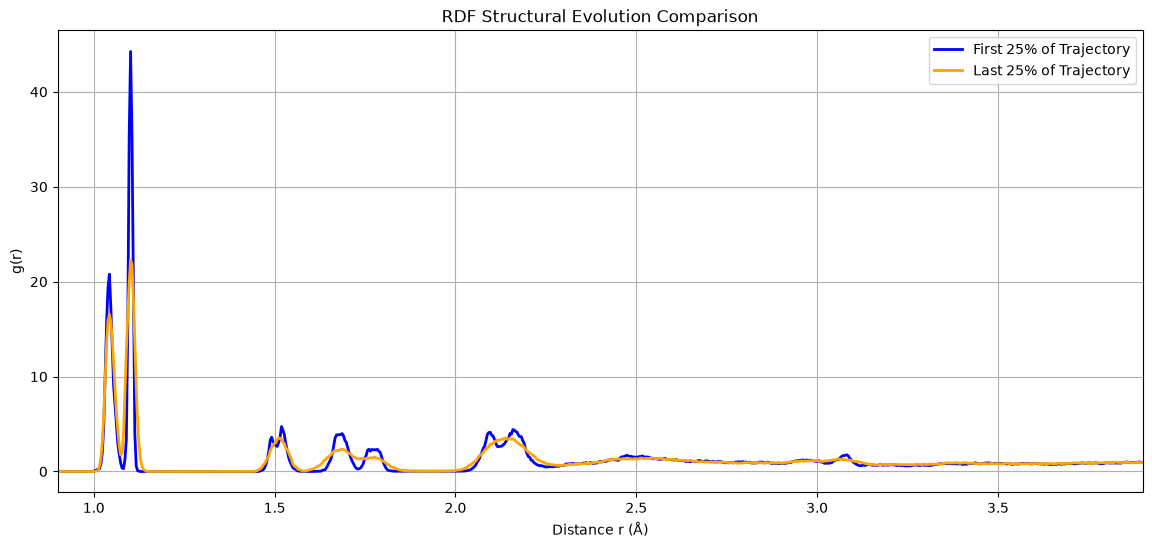

In [29]:
plt.figure(figsize=(14, 6)) 
plt.xlim([0.9,3.9])
plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='First 25% of Trajectory')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='Last 25% of Trajectory')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title('RDF Structural Evolution Comparison')
plt.grid(True)
plt.legend()
plt.show()

The curves are overlapped --> no phase transition; but different (smoother at the end)--> **must check for convergence** (ie. when equilibirum reached in the simulation):.

## Convergence check

In this part we check when equilibrium is reached in the simulation, looking at various statistics. For reasons and details on each, see the respective sections later in the notebook.

In [31]:
def check_equilibration(observable, name, dt=1):
    """
    observable: 1D array, one scalar value per frame
    Returns t0 (equilibration frame), g (statistical inefficiency),
    Neff (effective uncorrelated sample count)
    """
    t0, g, Neff = timeseries.detect_equilibration(observable)
    print(f"[{name}] t0 = {t0} (frame {t0*dt}), "
          f"g = {g:.2f}, N_eff = {Neff:.1f} / {len(observable)}")
    return t0, g, Neff

In [ ]:
# DERIVED TEMPERATURE

# on all frames and ALL ATOMS:
timestep_in_fs = 0.5

all_velocities = []
for i in range(len(images) - 1):
    delta_p = images[i+1].get_positions() - images[i].get_positions()
    delta_p, _ = find_mic(delta_p, images[i].get_cell(), pbc=images[i].get_pbc())
    all_velocities.append(delta_p / timestep_in_fs)
all_velocities = np.array(all_velocities)

N_atoms = len(images[0])
dof = 3 * N_atoms - 3   # only remove 3 for center-of-mass translation (see "Temperature" section for more details)

temperatures = []
for i, atoms in enumerate(images[:-1]):
    m = atoms.get_masses()
    v_ase = all_velocities[i] / units.fs
    ek = 0.5 * np.sum(m[:, np.newaxis] * v_ase**2)
    temperatures.append((2 * ek) / (dof * units.kB))
temperatures = np.array(temperatures) 

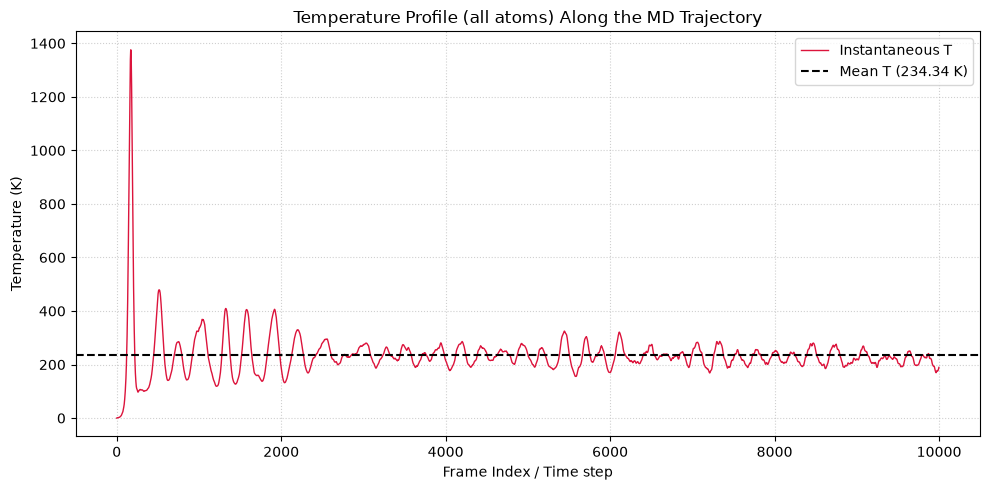

In [ ]:
time_steps=np.arange(len(images))[:-1]
mean_temperature=np.mean(temperatures)

plt.figure(figsize=(10, 5))
plt.plot(time_steps, temperatures, color="crimson", linewidth=1, label="Instantaneous T")
plt.axhline(y=mean_temperature, color="black", linestyle="--", linewidth=1.5, label=f"Mean T ({mean_temperature:.2f} K)")

plt.xlabel("Frame Index / Time step")
plt.ylabel("Temperature (K)")
plt.title("Temperature Profile (all atoms) Along the MD Trajectory")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

plt.show()

In [ ]:
all_temperatures = {
    "temperatures": temperatures,
    "time_steps": time_steps,
    "mean_temperature": mean_temperature,
}

pickle_path = os.path.join(output_dir, "all_temperatures.pickle")

with open(
    pickle_path,
    "wb",
) as f:
    pickle.dump(all_temperatures, f)

In [37]:
! grep "TEBEG" $INCAR_FILE # actual temperature

TEBEG = 300


In [ ]:
# Partial temperature by species
first_frame = images[0]
masses = first_frame.get_masses()
elements = ['Sn', 'I', 'N', 'C', 'H']
symbols = np.array(first_frame.get_chemical_symbols())

# Dictionary to store results
T_element = {}          # full time series per element
T_element_mean = {}     # mean over last 2500 frames

for element in elements:
    mask = symbols == element
    n = mask.sum()
    dof_el = 3 * n  # no COM subtraction for a diagnostic split
    T_el = []
    for i in range(len(all_velocities)):
        v = all_velocities[i][mask] / fs   # convert to Å/fs? Actually all_velocities already in Å/fs, check units
        m = masses[mask]
        ek = 0.5 * np.sum(m[:, np.newaxis] * v**2)
        T_el.append(2 * ek / (dof_el * kB))
    # Store full list and mean (last 2500 frames)
    T_element[element] = np.array(T_el)
    T_element_mean[element] = np.mean(T_el[-2500:])

# Print or access results
for element in elements:
    print(f"{element}: {T_element_mean[element]:.2f} K (mean over last 2500 frames)")

Sn: 543.52 K (mean over last 2500 frames)
I: 639.92 K (mean over last 2500 frames)
N: 299.87 K (mean over last 2500 frames)
C: 220.86 K (mean over last 2500 frames)
H: 67.67 K (mean over last 2500 frames)


In [ ]:
element_temperatures = {
    "elements": elements,
    "T_element": T_element,
    "T_element_mean": T_element_mean,
}

pickle_path=os.path.join(output_dir, "element_temperatures.pickle")

with open(pickle_path, "wb") as f:
    pickle.dump(element_temperatures, f)

In [ ]:
# hydrogen apparent speed is suppressed the most using finite- differences to compute velocoties
# - inherent limitation in the simulation: time step of 15 fs too small to catch some H oscillations, probably

In [44]:

# --- Apply to independent scalar observables ---
# 1. Temperature (already computed above as `temperatures`)
t0_T, g_T, Neff_T = check_equilibration(np.array(temperatures), "Temperature", dt=1) 


[Temperature] t0 = 167 (frame 167), g = 64.78, N_eff = 151.8 / 9999


In [46]:
# MAXIMUM HEIGHT AND FULL WIDTH AT HALF MAXIMUM (FWHM) OF FIRST MAXIMUM OF THE TOTAL RDF

nbins = 1000
window_size = 20

g_max_history = []
fwhm_history = []
time_steps = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_rdfs = []
    for atoms in images[start_idx : start_idx + window_size]:
        rdf_vals, distances = get_rdf(atoms, rmax=rmax, nbins=nbins)
        window_rdfs.append(rdf_vals)
    window_avg_rdf = np.mean(window_rdfs, axis=0)

    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0

    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    if len(left_indices) > 0 and len(right_indices) > 0:
        fwhm = distances[max_idx + right_indices[0]] - distances[left_indices[-1]]
    else:
        fwhm = np.nan

    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)

g_max_history = np.array(g_max_history)
fwhm_history = np.array(fwhm_history)

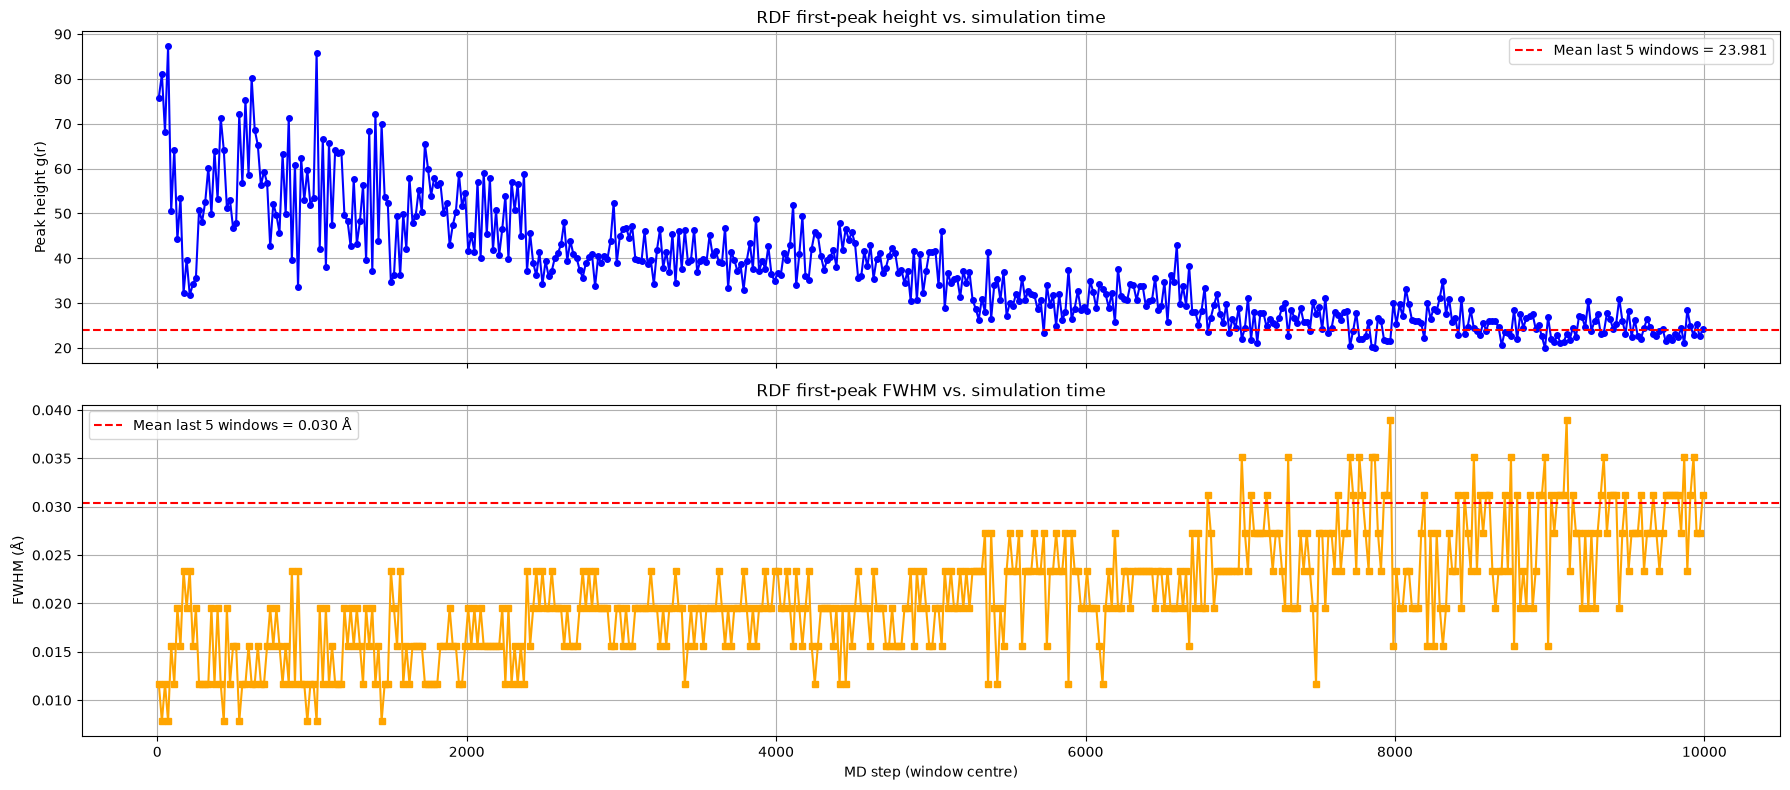

In [47]:
# Assuming g_max_history, fwhm_history, time_steps are defined as above

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# --- Peak height (g_max) ---
ax1.plot(time_steps, g_max_history, 'o-', color='blue', lw=1.5, markersize=4)
ax1.axhline(np.mean(g_max_history[-5:]), color='red', linestyle='--', 
            label=f"Mean last 5 windows = {np.mean(g_max_history[-5:]):.3f}") # last 5 windows; window covers 10_000/20= 500 frames; so 500*5 = 2500 frames shown
ax1.set_ylabel('Peak height g(r)')
ax1.grid(True)
ax1.legend()
ax1.set_title('RDF first‐peak height vs. simulation time')

# --- FWHM ---
ax2.plot(time_steps, fwhm_history, 's-', color='orange', lw=1.5, markersize=4)
ax2.axhline(np.mean(fwhm_history[-5:]), color='red', linestyle='--',
            label=f"Mean last 5 windows = {np.mean(fwhm_history[-5:]):.3f} Å")
ax2.set_xlabel('MD step (window centre)')
ax2.set_ylabel('FWHM (Å)')
ax2.grid(True)
ax2.legend()
ax2.set_title('RDF first‐peak FWHM vs. simulation time')

plt.tight_layout()
plt.show()

In [ ]:
fwhm_gmax_history = {
    "time_steps": time_steps,
    "g_max_history": g_max_history,
    "fwhm_history": fwhm_history,
}

pickle_path=os.path.join(output_dir, fwhm_gmax_history.pickle)
with open(
    pickle_path,
    "wb",
) as f:
    pickle.dump(fwhm_gmax_history, f)

In [49]:

# 2. RDF peak height / width (already computed as g_max_history, fwhm_history)
t0_gmax, g_gmax, Neff_gmax = check_equilibration(np.array(g_max_history), "g_max", dt=window_size)
t0_fwhm, g_fwhm, Neff_fwhm = check_equilibration(np.array(fwhm_history), "FWHM", dt=window_size)


[g_max] t0 = 420 (frame 8400), g = 1.82, N_eff = 44.5 / 500
[FWHM] t0 = 342 (frame 6840), g = 4.19, N_eff = 37.9 / 500


In [50]:
pbc = images[0].get_pbc()

# accumulate unwrapped displacement frame-to-frame
unwrapped_disp = np.zeros_like(images[0].get_positions())
msd_full_mic = [0.0]

prev_pos = images[0].get_positions()
for atoms in images[1:]:
    pos = atoms.get_positions()
    step_disp = pos - prev_pos
    step_disp, _ = find_mic(step_disp, cell, pbc=pbc)
    unwrapped_disp += step_disp
    msd_full_mic.append(np.mean(np.sum(unwrapped_disp**2, axis=1)))
    prev_pos = pos

msd_full_mic = np.array(msd_full_mic)

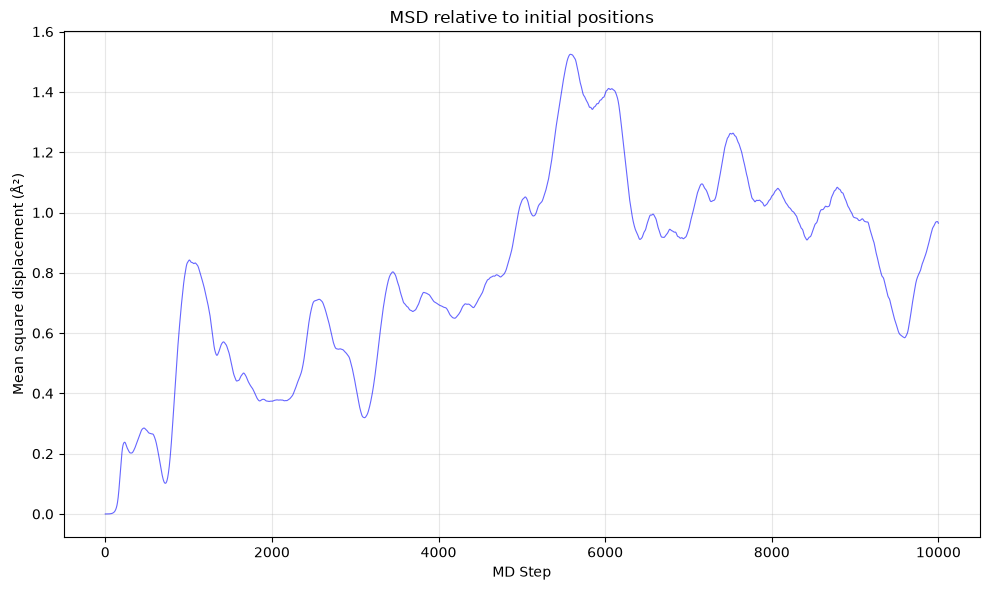

In [56]:
steps = np.arange(len(msd_full_mic))

plt.figure(figsize=(10, 6))
plt.plot(steps, msd_full_mic, lw=0.8, alpha=0.6, color='blue', label='Raw MSD')

plt.xlabel('MD Step')
plt.ylabel('Mean square displacement (Å²)')
plt.title('MSD relative to initial positions')
plt.grid(True, alpha=0.3)
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
msd_history = {
    "steps": steps,
    "msd_full_mic": msd_full_mic,
}

pickle_path=os.pah.join(output_dir, msd_history.pickle)

with open(
    pickle_path,
    "wb",
) as f:
    pickle.dump(msd_history, f)

In [57]:
# 3. Total MSD (already computed as msd_full_mic)
t0_msd, g_msd, Neff_msd = check_equilibration(msd_full_mic, "MSD (full)")


[MSD (full)] t0 = 5954 (frame 5954), g = 480.62, N_eff = 8.4 / 10000


In [59]:
# ENERGIES (from OUTCAR)

outcar_images=read(outcar_file, index=':')

energies = np.array([atoms.get_potential_energy() for atoms in outcar_images])


In [ ]:
energies_dict = {
    "energies": energies,
}

pickle_path=os.path.join(output_dir, "energies_dict.pickle")

with open(
    pickle_path,
    "wb",
) as f:
    pickle.dump(energies_dict, f)

In [ ]:
t0_E, g_E, Neff_E = check_equilibration(energies, "Total Energy", dt=1)


[Total Energy] t0 = 86 (frame 86), g = 205.61, N_eff = 48.2 / 10000


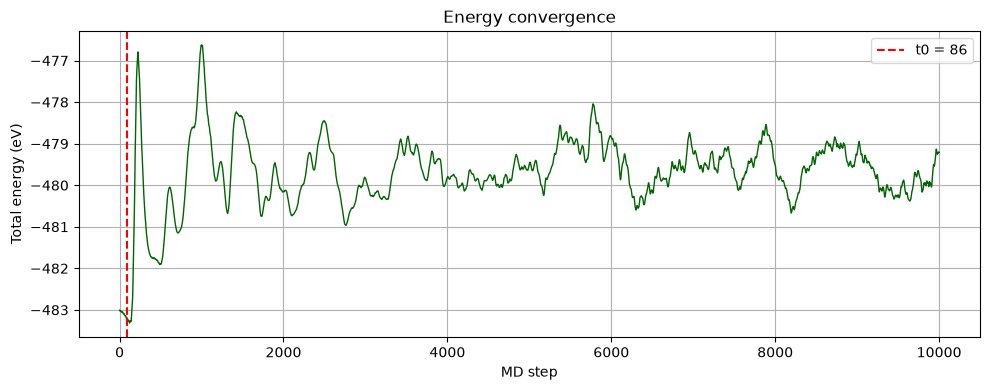

In [65]:

# Plot energy alongside for visual check
plt.figure(figsize=(10, 4))
plt.plot(energies, lw=1, color='darkgreen')
plt.axvline(t0_E, color='red', linestyle='--', label=f't0 = {t0_E}')
plt.xlabel('MD step')
plt.ylabel('Total energy (eV)')
plt.title('Energy convergence')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
t0_T_frame     = t0_T
t0_gmax_frame  = t0_gmax * window_size
t0_fwhm_frame  = t0_fwhm * window_size
t0_msd_frame   = t0_msd    # steps are directly frame indices
t0_E_frame = t0_E          # steps are directly frame indices

t0_consensus = max(t0_T_frame, t0_gmax_frame, t0_fwhm_frame, t0_msd_frame, t0_E_frame)
print(f"Consensus equilibration frame: {t0_consensus}")

Consensus equilibration frame: 8400


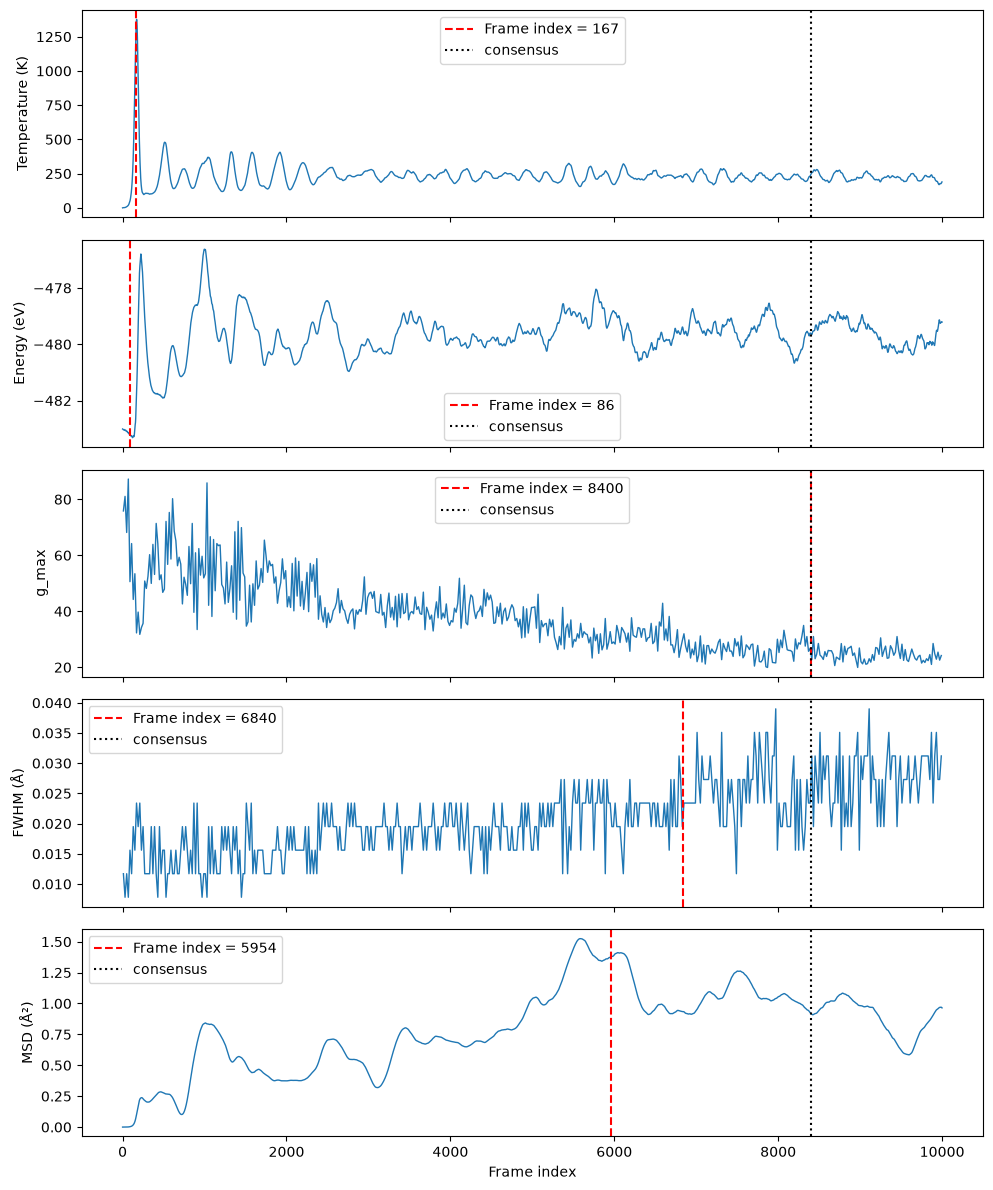

In [67]:
fig, axs = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

x_T    = np.arange(len(temperatures))
x_E    = np.arange(len(energies))
x_msd  = np.arange(len(msd_full_mic))
x_gmax = time_steps
x_fwhm = time_steps

t0s = [t0_T, t0_E, t0_gmax_frame, t0_fwhm_frame, t0_msd]
data_list = [temperatures, energies, g_max_history, fwhm_history, msd_full_mic]
x_list = [x_T, x_E, x_gmax, x_fwhm, x_msd]
names = ["Temperature (K)", "Energy (eV)", "g_max", "FWHM (Å)", "MSD (Å²)"]

for ax, x, data, name, t0 in zip(axs, x_list, data_list, names, t0s):
    ax.plot(x, data, lw=1)
    ax.axvline(t0, color="red", ls="--", label=f"Frame index = {t0}")
    ax.axvline(t0_consensus, color="black", ls=":", label="consensus")
    ax.set_ylabel(name)
    ax.legend()

axs[-1].set_xlabel("Frame index")
plt.tight_layout()
plt.show()

In [70]:
convergence_results = {

    't0_T': t0_T,
    'g_T': g_T,
    'Neff_T': Neff_T,
    't0_gmax': t0_gmax,
    'g_gmax': g_gmax,
    'Neff_gmax': Neff_gmax,
    't0_fwhm': t0_fwhm,
    'g_fwhm': g_fwhm,
    'Neff_fwhm': Neff_fwhm,
    't0_msd': t0_msd,
    'g_msd': g_msd,
    'Neff_msd': Neff_msd,
    't0_E': t0_E,
    'g_E': g_E,
    'Neff_E': Neff_E,

    't0_T_frame': t0_T_frame,
    't0_gmax_frame': t0_gmax_frame,
    't0_fwhm_frame': t0_fwhm_frame,
    't0_msd_frame': t0_msd_frame,
    't0_E_frame': t0_E_frame,

    't0_consensus': t0_consensus,

    'window_size': window_size,
}

pickle_path=os.path.join(output_dir, "convergence_results.pickle")

with open(pickle_path, "wb") as f:
    pickle.dump(convergence_results, f)

**Important note**: from here on we proceed in the analysis using only the data at equilibrium

In [71]:
my_equilibrium_file="./new_data/1.NVT_300/A.1_10K/cleaned_dataset_equilibrium.extxyz" 

In [72]:
clean_dataset(
    outcar_file=outcar_file,
    destination_file=my_equilibrium_file,
    start_idx=6840
)

Retrieved 3160 structures from OUTCAR.
File saved as ./new_data/1.NVT_300/A.1_10K/cleaned_dataset_equilibrium.extxyz


0

In [82]:
images_equilibrium=read(my_equilibrium_file, index=':')

## RDF-based analysis -- at equilibrium

In [89]:
len(all_rdfs[2])

100

In [ ]:
# The original `images` list contained the full trajectory.
# We already computed `all_rdfs` for every frame in that full trajectory.
# Now we take the equilibrium part starting at frame 6840.
# (this saves us some computation time)

start_eq = 6840
equilibrium_rdfs = all_rdfs[start_eq:]   # slice the original RDF list

# Compute average RDF over equilibrium frames
avg_rdf_eq = np.mean(equilibrium_rdfs, axis=0)

# Number density and coordination number (same as before, using equilibrium avg RDF)
reference_atoms = images_equilibrium[0]
volume = reference_atoms.get_volume()
num_target_atoms = len(reference_atoms)
print("N atoms (equilibrium): ", num_target_atoms, "in volume:", volume)
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf_eq
coordination_number = np.cumsum(coordination_integrand) * dr

# Potential of Mean Force (PMF)
with np.errstate(divide='ignore'):
    pmf_eq = -np.log(avg_rdf_eq)
pmf_eq[np.isinf(pmf_eq)] = np.nan

# --- Rolling window peak tracking (g_max and FWHM) for equilibrium part ---
# Use the same window_size, but now on the equilibrium RDFs
window_size = 20
total_eq_frames = len(equilibrium_rdfs)
g_max_eq = []
fwhm_eq = []
time_steps_eq = []

for start_idx in range(0, total_eq_frames - window_size + 1, window_size):
    window_rdfs = equilibrium_rdfs[start_idx : start_idx + window_size]
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    if len(left_indices) > 0 and len(right_indices) > 0:
        fwhm = distances[max_idx + right_indices[0]] - distances[left_indices[-1]]
    else:
        fwhm = np.nan
        
    g_max_eq.append(g_max)
    fwhm_eq.append(fwhm)
    time_steps_eq.append(start_idx + window_size // 2)   # relative frame index within equilibrium

# Convert to numpy arrays
g_max_eq = np.array(g_max_eq)
fwhm_eq = np.array(fwhm_eq)
time_steps_eq = np.array(time_steps_eq)

N atoms (equilibrium):  100 in volume: 1474.4473736057512


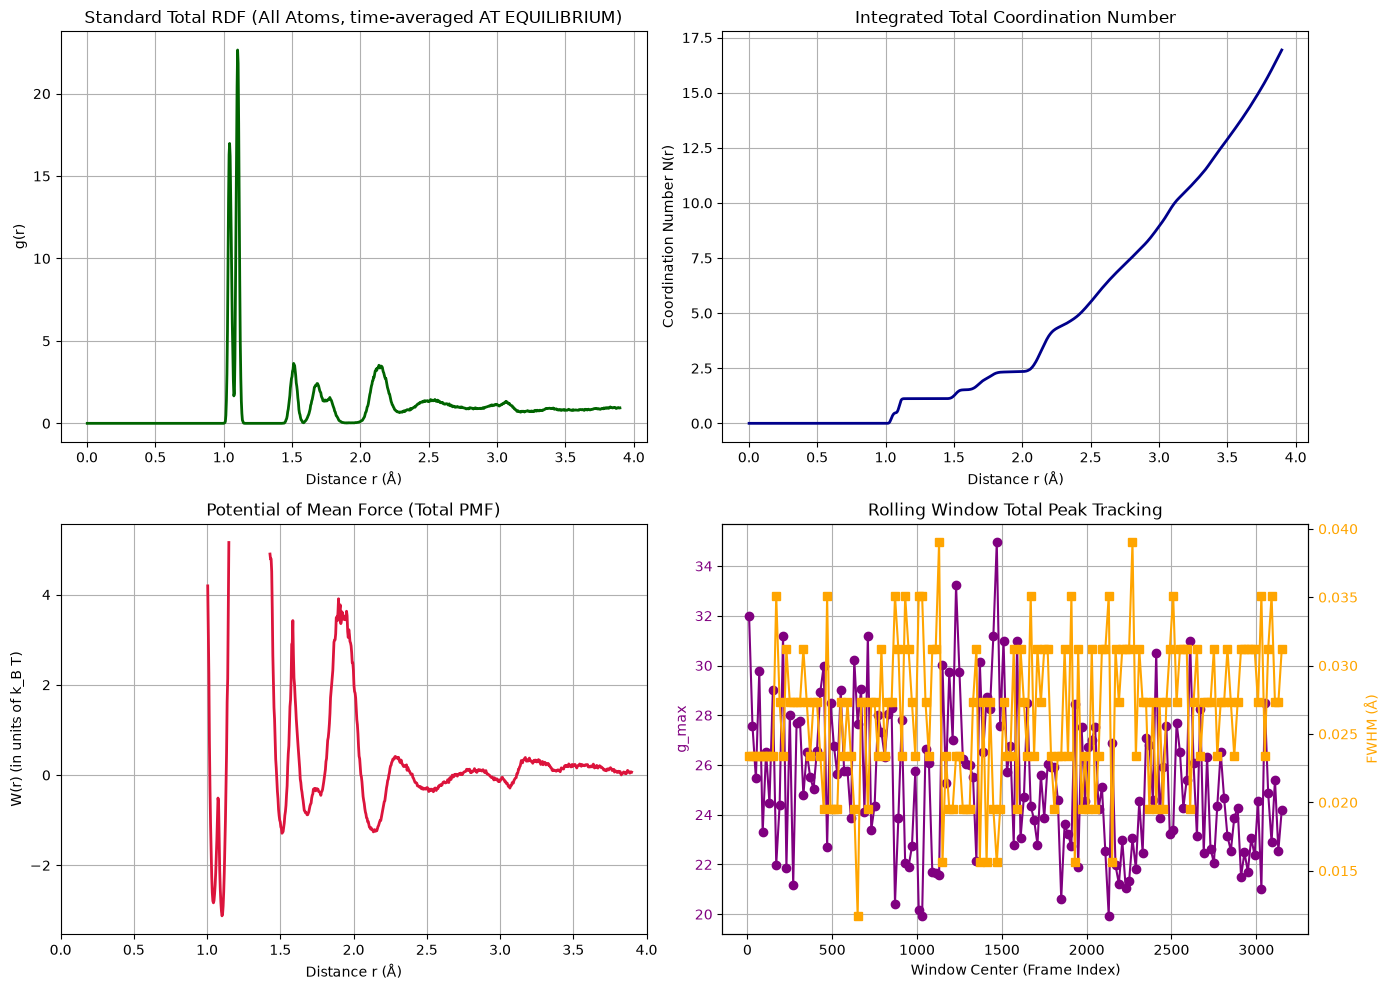

In [102]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf_eq, color='darkgreen', lw=2)
axs[1,0].set_xlim([0., 4.])
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title('Standard Total RDF (All Atoms, time-averaged AT EQUILIBRIUM)')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Total Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf_eq, color='crimson', lw=2)
axs[1,0].set_xlim([0., 4.])
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (Total PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps_eq, g_max_eq, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps_eq, fwhm_eq, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Total Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [103]:
equilibrium_rdf_analysis = {

    "distances": distances,
    "avg_rdf_eq": avg_rdf_eq,
    "coordination_number": coordination_number,
    "pmf_eq": pmf_eq,

    "time_steps_eq": time_steps_eq,
    "g_max_eq": g_max_eq,
    "fwhm_eq": fwhm_eq,

    "window_size": window_size,
    "start_eq": start_eq,   # since all_rdfs already corresponds to equilibrium part
}

pickle_path = os.path.join(output_dir, "equilibrium_rdf_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(equilibrium_rdf_analysis, f)

### Individual pairs

Now we want to study the different atoms (we take individual pairs):

In [ ]:
rmax = 3.9
nbins = 100
window_size = 20

pairs = [
    ('Sn', 'I'),
    ('I', 'I'),
    ('N', 'I'),
    ('H', 'I'),
    ('C', 'N'),
    ('H', 'N'),
    ('H', 'C'),
]

total_eq_frames = len(images_equilibrium)
reference_atoms = images_equilibrium[0]
volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()


In [110]:
def compute_pair_analysis(selected_elements):
    all_rdfs = []
    distances = None
    for atoms in images_equilibrium:
        rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        all_rdfs.append(rdf_values)
    avg_rdf = np.mean(all_rdfs, axis=0)

    num_target_atoms = symbols.count(selected_elements[1])
    number_density = num_target_atoms / volume

    dr = distances[1] - distances[0]
    coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
    coordination_number = np.cumsum(coordination_integrand) * dr

    with np.errstate(divide='ignore'):
        pmf = -np.log(avg_rdf)
    pmf[np.isinf(pmf)] = np.nan

    time_steps = []
    g_max_history = []
    fwhm_history = []

    for start_idx in range(0, total_eq_frames - window_size + 1, window_size):
        window_images = images_equilibrium[start_idx : start_idx + window_size]
        window_rdfs = []
        for atoms in window_images:
            rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
            window_rdfs.append(rdf_vals)
        window_avg_rdf = np.mean(window_rdfs, axis=0)

        max_idx = np.argmax(window_avg_rdf)
        g_max = window_avg_rdf[max_idx]
        half_max = g_max / 2.0

        left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
        right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]

        if len(left_indices) > 0 and len(right_indices) > 0:
            r_left = distances[left_indices[-1]]
            r_right = distances[max_idx + right_indices[0]]
            fwhm = r_right - r_left
        else:
            fwhm = np.nan

        g_max_history.append(g_max)
        fwhm_history.append(fwhm)
        time_steps.append(start_idx + window_size // 2)

    return {
        "distances": distances,
        "avg_rdf": avg_rdf,
        "coordination_number": coordination_number,
        "pmf": pmf,
        "time_steps": np.array(time_steps),
        "g_max_history": np.array(g_max_history),
        "fwhm_history": np.array(fwhm_history),
    }



In [ ]:
partial_results_eq = {}

for pair in pairs:
    partial_results_eq[pair] = compute_pair_analysis(pair)
    print(f"Done computing for pair {pair}")

# took 17 minutes on CPU


In [115]:
pickle_path = os.path.join(output_dir, "partial_results_eq.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(partial_results_eq, f)



   SECTION: Inorganic



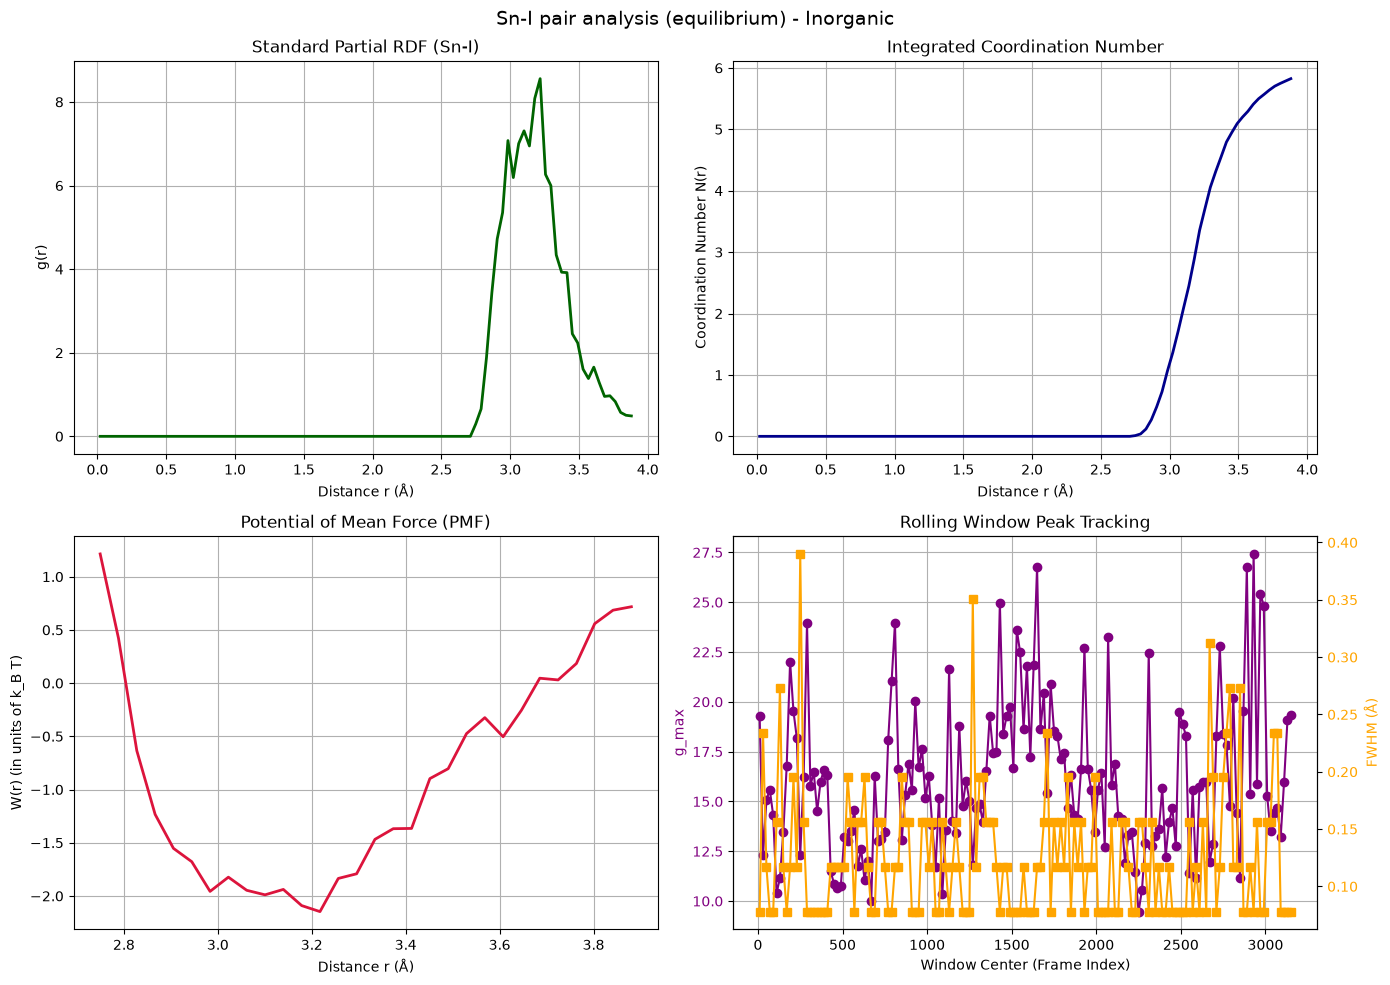

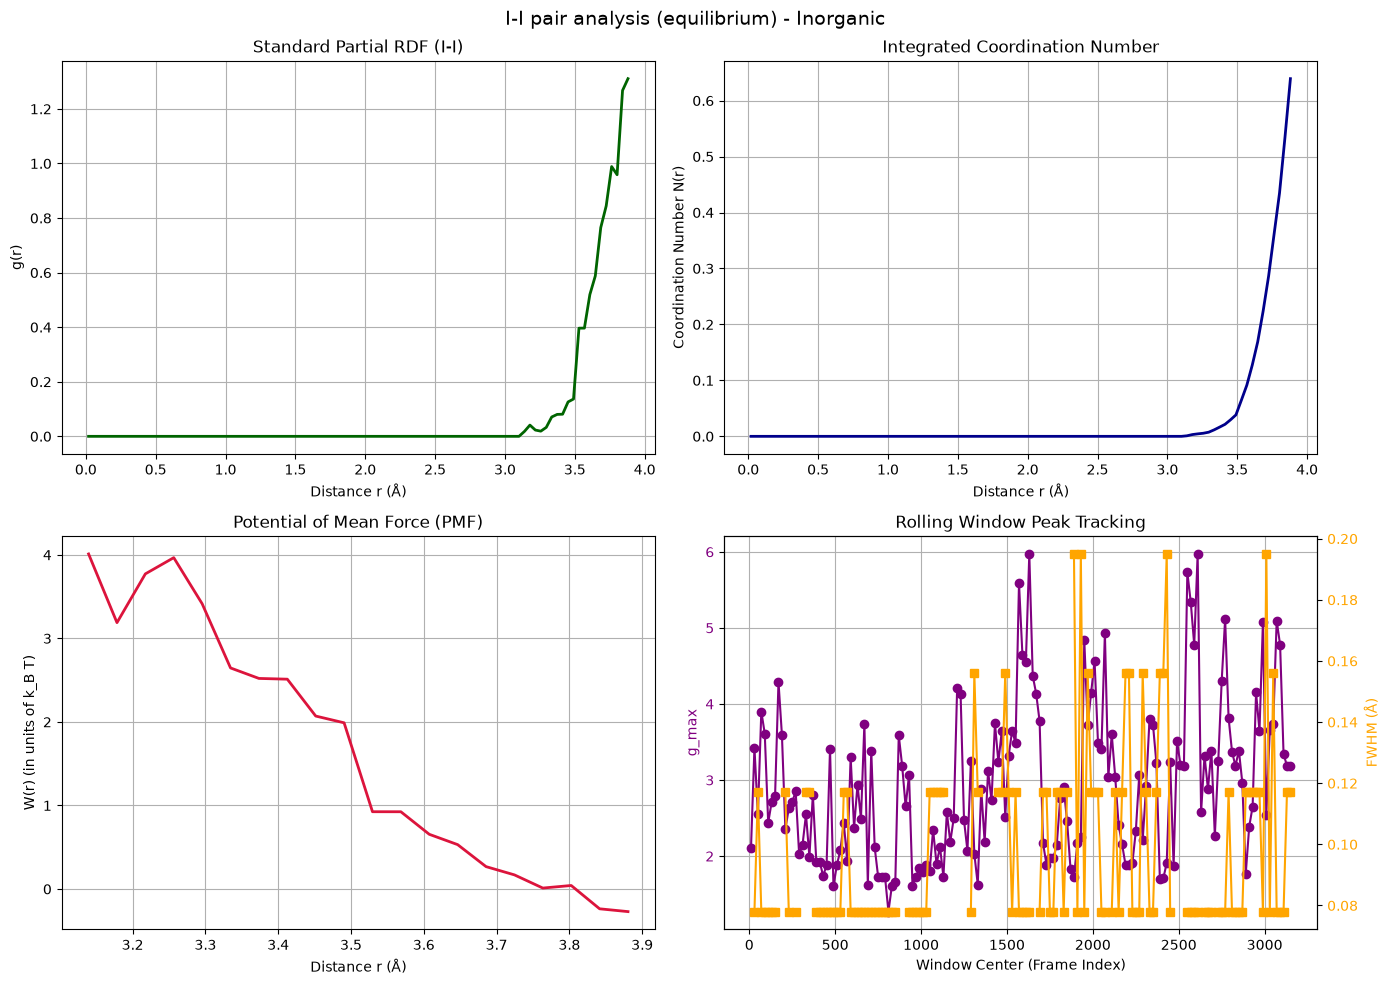


   SECTION: Organic vs Inorganic



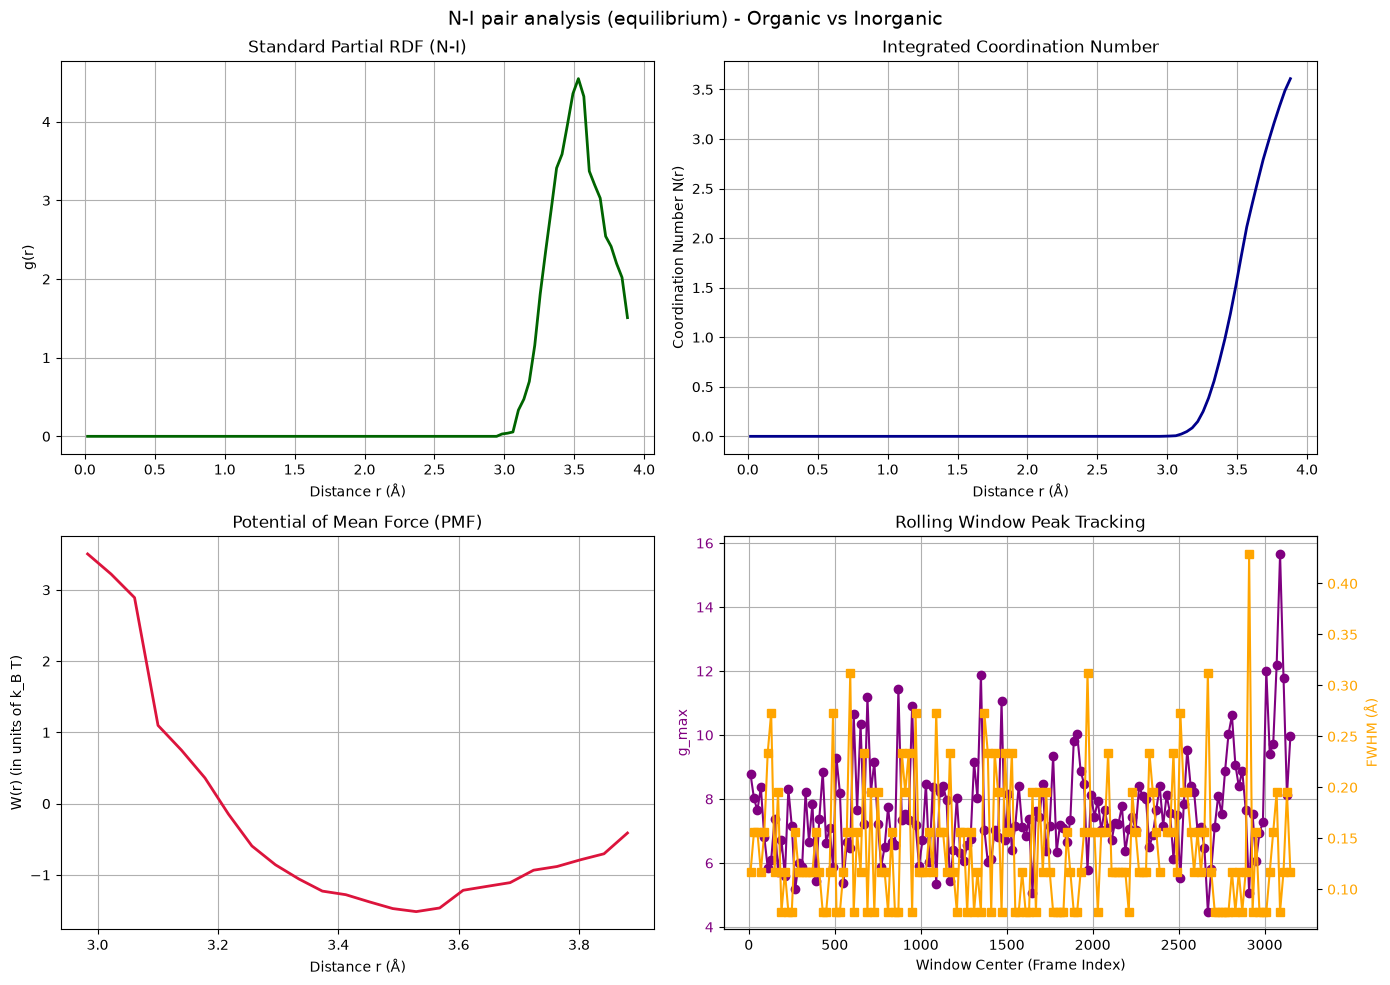

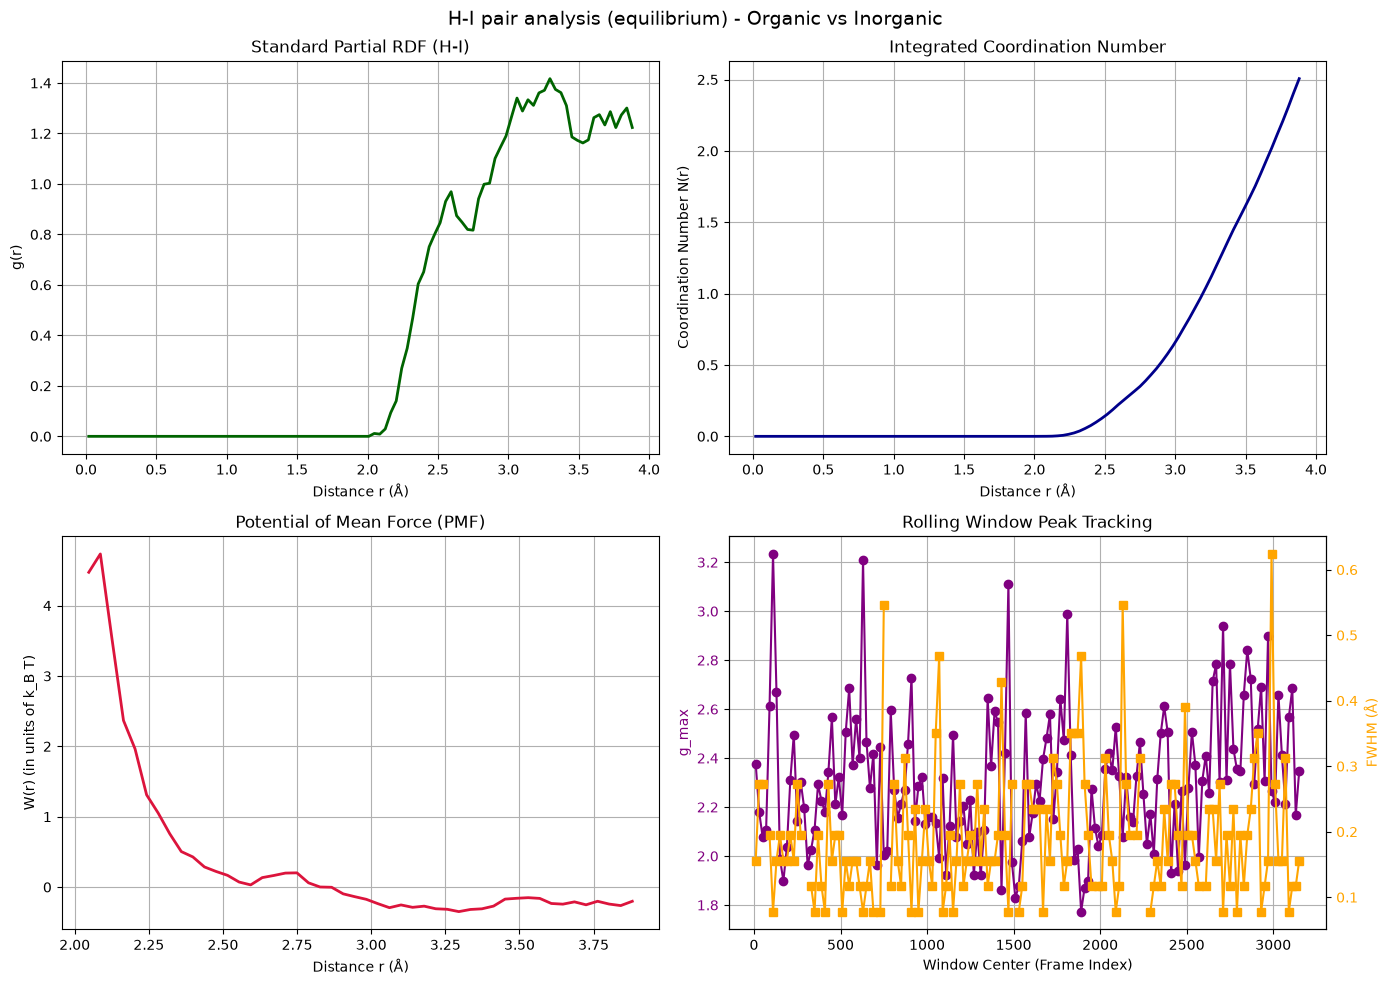


   SECTION: Organic



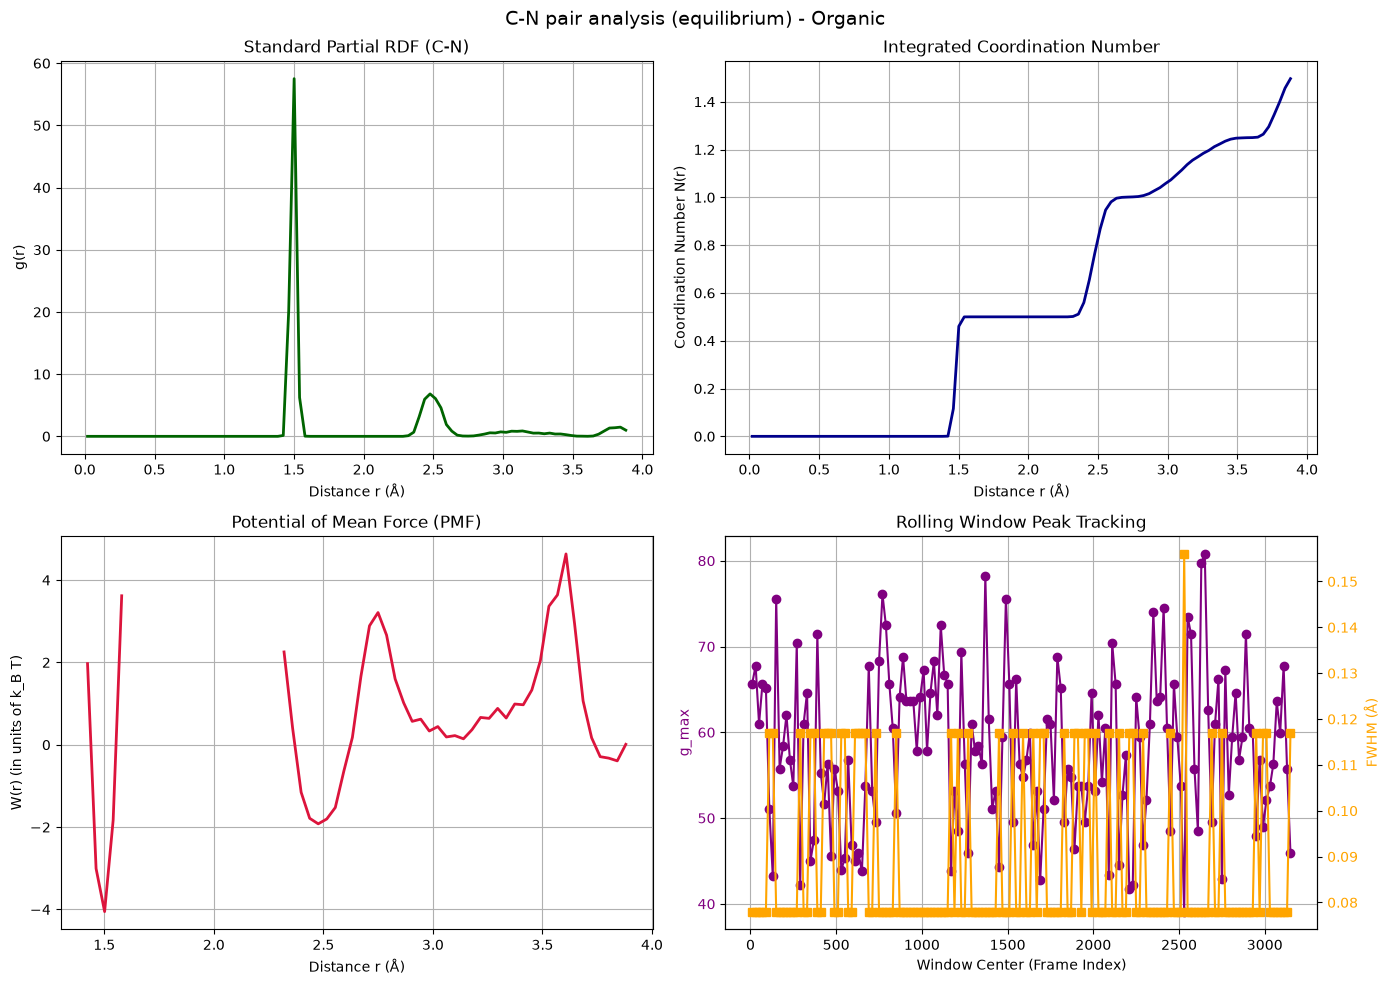

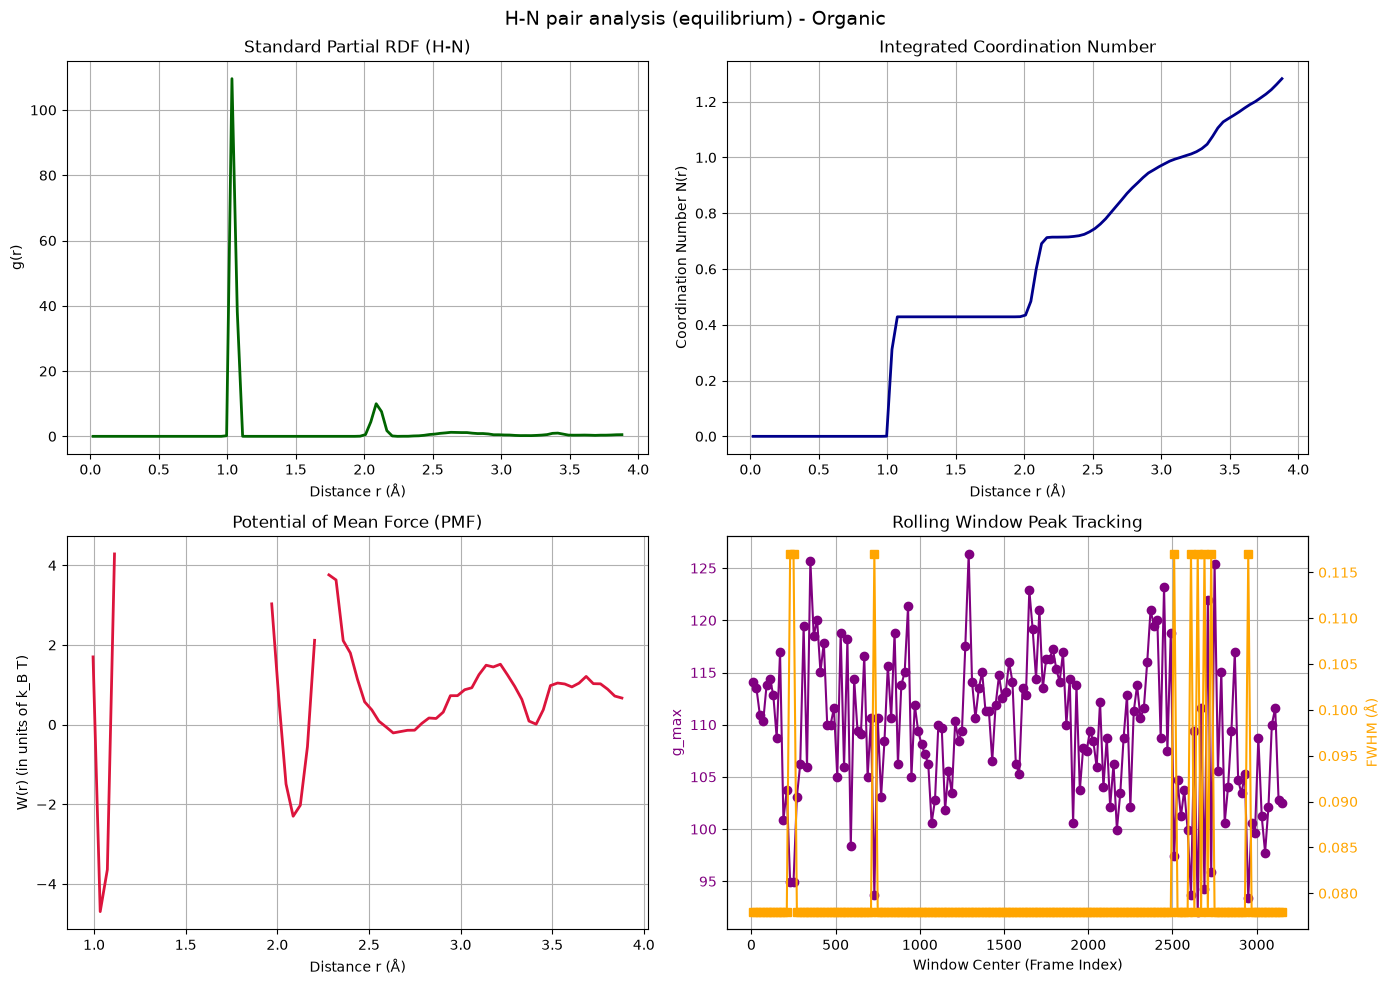

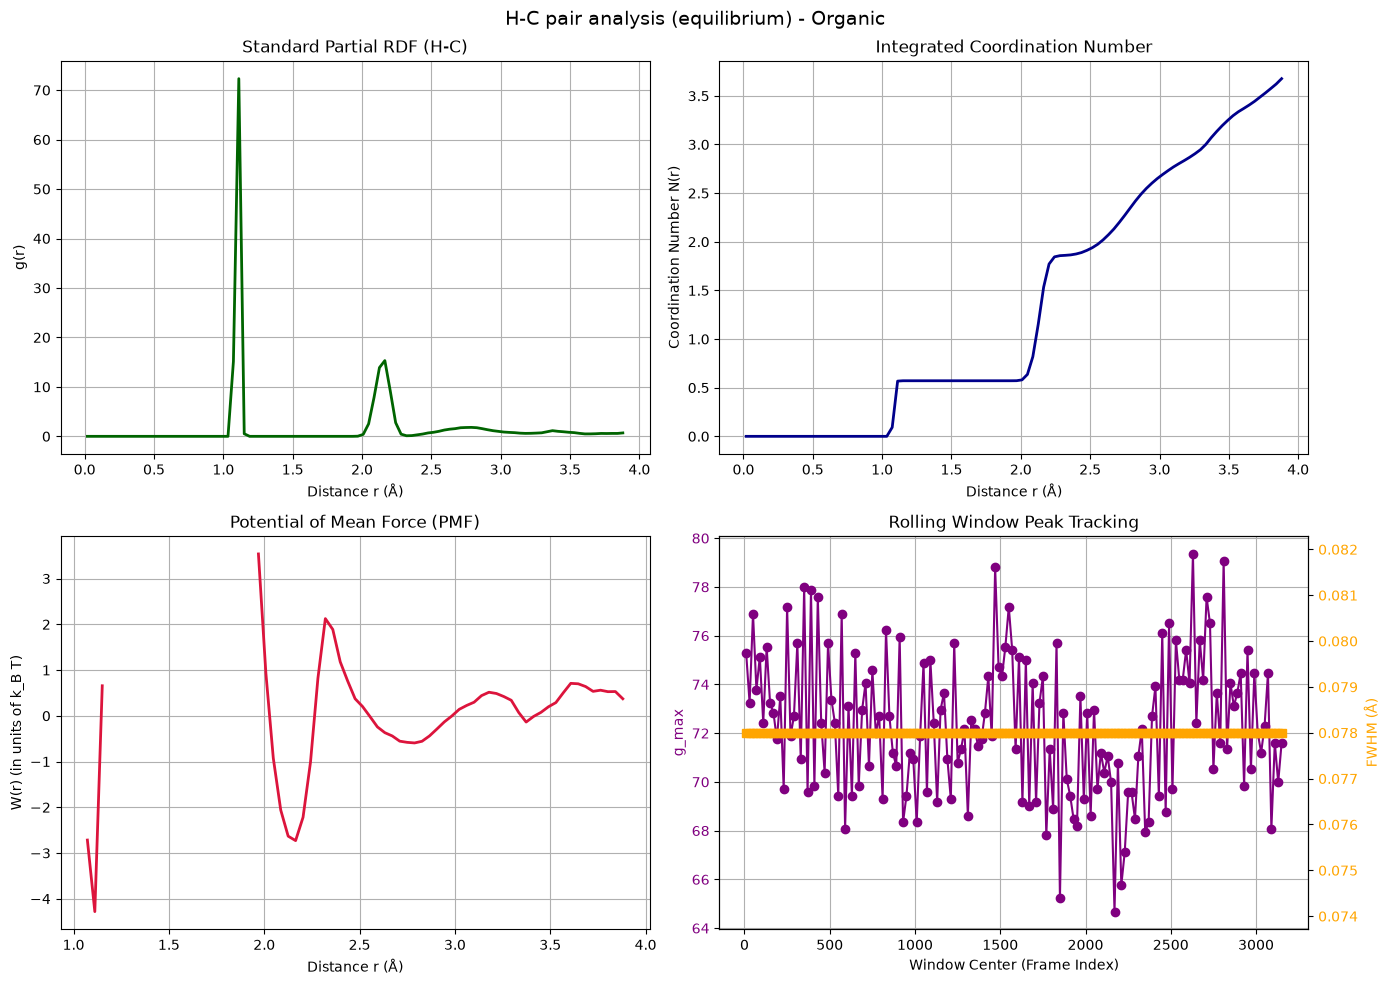

In [ ]:
# Define sections
sections = {
    "Inorganic": [('Sn', 'I'), ('I', 'I')],
    "Organic vs Inorganic": [('N', 'I'), ('H', 'I')],
    "Organic": [('C', 'N'), ('H', 'N'), ('H', 'C')]
}

for section_name, pairs_in_section in sections.items():
    print(f"\n{'='*60}")
    print(f"   SECTION: {section_name}")
    print(f"{'='*60}\n")
    
    for pair in pairs_in_section:
        res = partial_results_eq[pair]
        distances = res["distances"]
        avg_rdf = res["avg_rdf"]
        coordination_number = res["coordination_number"]
        pmf = res["pmf"]
        time_steps = res["time_steps"]
        g_max_history = res["g_max_history"]
        fwhm_history = res["fwhm_history"]

        fig, axs = plt.subplots(2, 2, figsize=(14, 10))

        axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
        axs[0, 0].set_xlabel('Distance r (Å)')
        axs[0, 0].set_ylabel('g(r)')
        axs[0, 0].set_title(f'Standard Partial RDF ({pair[0]}-{pair[1]})')
        axs[0, 0].grid(True)

        axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
        axs[0, 1].set_xlabel('Distance r (Å)')
        axs[0, 1].set_ylabel('Coordination Number N(r)')
        axs[0, 1].set_title('Integrated Coordination Number')
        axs[0, 1].grid(True)

        axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
        axs[1, 0].set_xlabel('Distance r (Å)')
        axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
        axs[1, 0].set_title('Potential of Mean Force (PMF)')
        axs[1, 0].grid(True)

        axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
        axs[1, 1].set_xlabel('Window Center (Frame Index)')
        axs[1, 1].set_ylabel('g_max', color='purple')
        axs[1, 1].tick_params(axis='y', labelcolor='purple')

        ax2 = axs[1, 1].twinx()
        ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
        ax2.set_ylabel('FWHM (Å)', color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')
        axs[1, 1].set_title('Rolling Window Peak Tracking')
        axs[1, 1].grid(True)

        fig.suptitle(f'{pair[0]}-{pair[1]} pair analysis (equilibrium) - {section_name}', fontsize=14)
        plt.tight_layout()
        plt.show()

In [ ]:
# first peak in C-N is bond within organic chain, second is C vs N at the other end of the chain, and other two likely C vs N from other chains

In [ ]:
# firs peak in C-H is bond within chain

## ADF-based analysis

While the RDF tells you how far away neighboring atoms are, it completely ignores direction. It gives a 1D map of distances, but it cannot tell the difference between a highly symmetric crystal cluster and a disordered liquid shell if the average distances happen to be the same.

The ADF measures the probability distribution of angles (θ) formed by triplets of atoms.
Look at its nearest neighbors (let's say atom A and atom C) within a certain cutoff distance. Then measure the angle ∠ABC. The ADF is a histogram of all these triplets across your entire structure.

Because crystals are highly symmetric, their ADF plots show incredibly sharp, definitive spikes at exact geometric angles. This makes the ADF the ultimate tool to identify a crystal's local symmetry or lattice type.

For example, if you look only at the first coordination shell (the nearest neighbors), different crystal structures yield entirely different angular signatures:

    FCC (Face-Centered Cubic): You will see sharp peaks at exactly 60°, 90°, 120°, and 180°.

    BCC (Body-Centered Cubic): The peaks shift to 70.5°, 109.5°, and 180°.

    Diamond Structure (like Silicon or Carbon): You will see a massive single peak at 109.5° (the classic tetrahedral angle).

If crystal starts to melt or becomes amorphous, these sharp spikes will broaden out into smooth, wide hills because the rigid geometric angles are being distorted.

### Bond Angle Distribution (BAD) Calculation

This script computes the **Bond Angle Distribution (BAD)**—specifically measuring the bond angles ($\theta$) formed at a central atom by pairs of neighboring atoms belonging to the same chemical species. 

Here is the step-by-step breakdown of how the program isolates and computes these angles:

#### 1. Neighbor Identification and Filtering
For every frame in the trajectory, the script uses ASE's `neighbor_list` to find all neighboring atoms within a spatial cutoff :
* **Central Atom Check:** The code iterates through all atoms in the frame.
* **Neighbor Filtering:** From the neighbor list of a given central atom, it isolates the displacement vectors pointing strictly to neighbors (`valid_vectors`).

#### 2. Combinatorial Pairing of Identical Neighbors
If a central atom has at least two neighbors (`num_neighbors >= 2`), the script enters a nested loop to evaluate every unique pair of vectors ($\vec{v}_1$ and $\vec{v}_2$):
```python
for idx1 in range(num_neighbors):
    for idx2 in range(idx1 + 1, num_neighbors):
        v1 = valid_vectors[idx1]
        v2 = valid_vectors[idx2]

cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

probability_density = total_counts / (total_angles * bin_width)

### I-SN-I

In [119]:
center_element = 'Sn'
neighbor_element = 'I'

cutoff = 3.5 # similar as rmax before
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images_equilibrium:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles: 
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


Area (90° peak): 0.8054
Area (180° peak): 0.1946
Ratio (90/180): 4.1394


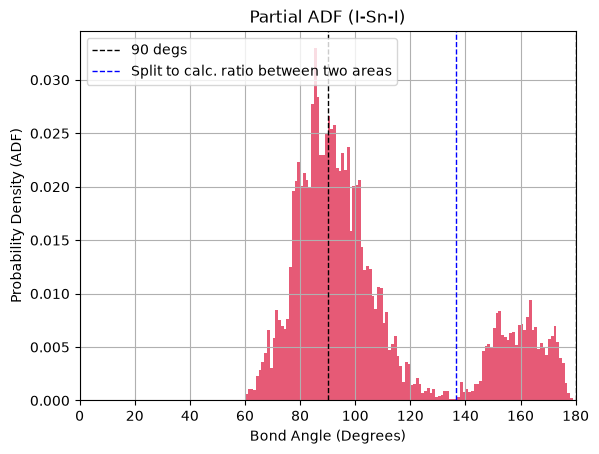

In [ ]:

# Vertical lines
plt.axvline(x=90, color='black', linestyle='--', linewidth=1, label='90 degs')
plt.axvline(x=180, color='black', linestyle='--', linewidth=1)

# Area ratio: find valley between peaks (restrict to 100-170° to avoid edges)
valley_mask = (bin_centers >= 100) & (bin_centers <= 170)
if np.any(valley_mask):
    valley_idx = np.argmin(probability_density[valley_mask]) + np.where(valley_mask)[0][0]
else:
    valley_idx = len(bin_centers) // 2  # fallback
plt.axvline(x=bin_centers[valley_idx], color='blue', linestyle='--', linewidth=1, label="Split to calc. ratio between two areas")

area_left = np.sum(probability_density[:valley_idx]) * bin_width
area_right = np.sum(probability_density[valley_idx:]) * bin_width
ratio = area_left / area_right if area_right > 0 else np.inf

print(f"Area (90° peak): {area_left:.4f}")
print(f"Area (180° peak): {area_right:.4f}")

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.show()

As expected:
* peaks near 90 degrees and 180 degs
* 90 degs count 12 of 15 couple, 180 degs counts 3 of 15 ---> ratio = 4

In [ ]:
#---> normalization ok

In [ ]:
partial_adf_i_sn_i = {
    "bin_centers": bin_centers,
    "probability_density": probability_density,
    "total_counts": total_counts,
    "bin_edges": bin_edges,
    "area_left": area_left,
    "area_right": area_right,
    "ratio": ratio,
    "valley_idx": valley_idx,
    "center_element": center_element,
    "neighbor_element": neighbor_element,
    "cutoff": cutoff,
    "bins": bins,
}

pickle_path = os.path.join(output_dir, "partial_adf_i_sn_i.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(partial_adf_i_sn_i, f)

### Sn-I-Sn 

In [124]:
cutoff = 3.5
center_element = 'I'
neighbor_element = 'Sn'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images_equilibrium:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


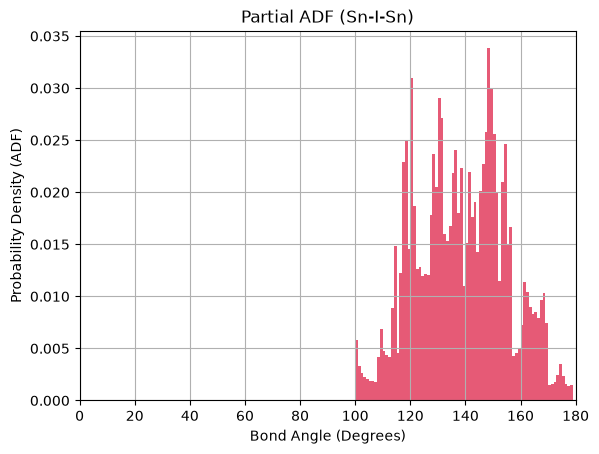

In [125]:
plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

In [126]:
partial_adf_sn_i_sn = {
    "bin_centers": bin_centers,
    "probability_density": probability_density,
    "total_counts": total_counts,
    "bin_edges": bin_edges,
    "area_left": area_left,
    "area_right": area_right,
    "ratio": ratio,
    "valley_idx": valley_idx,
    "center_element": center_element,
    "neighbor_element": neighbor_element,
    "cutoff": cutoff,
    "bins": bins,
}

pickle_path = os.path.join(output_dir, "partial_adf_sn_i_sn.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(partial_adf_sn_i_sn, f)

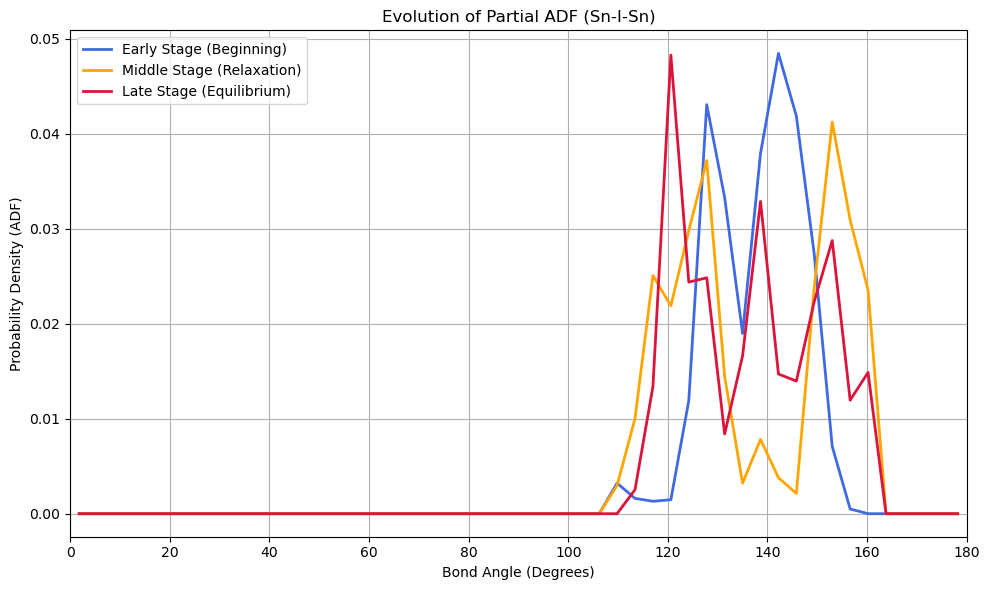

In [ ]:
center_element = 'I'
neighbor_element = 'Sn'
bins = 50
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

### H-C-H

In [127]:
cutoff = 1.5
center_element = 'C'
neighbor_element = 'H'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images_equilibrium:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


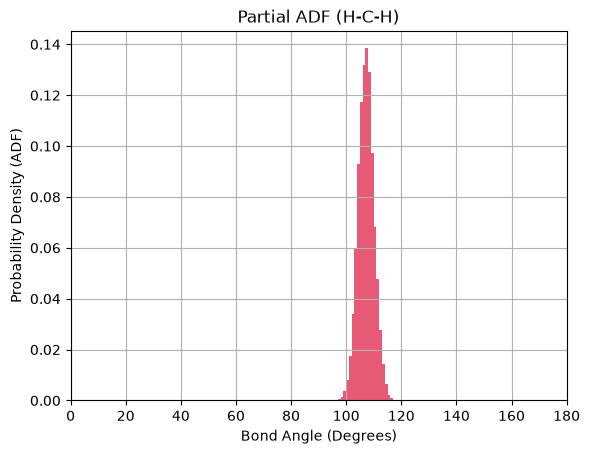

In [129]:

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

In [130]:
partial_adf_h_c_h = {
    "bin_centers": bin_centers,
    "probability_density": probability_density,
    "total_counts": total_counts,
    "bin_edges": bin_edges,
    "area_left": area_left,
    "area_right": area_right,
    "ratio": ratio,
    "valley_idx": valley_idx,
    "center_element": center_element,
    "neighbor_element": neighbor_element,
    "cutoff": cutoff,
    "bins": bins,
}

pickle_path = os.path.join(output_dir, "partial_adf_h_c_h.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(partial_adf_h_c_h , f)

In [ ]:
cutoff = 1.5
center_element = 'C'
neighbor_element = 'H'
bins = 50
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

### H-N-H

In [132]:
cutoff = 1.5
center_element = 'N'
neighbor_element = 'H'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images_equilibrium:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


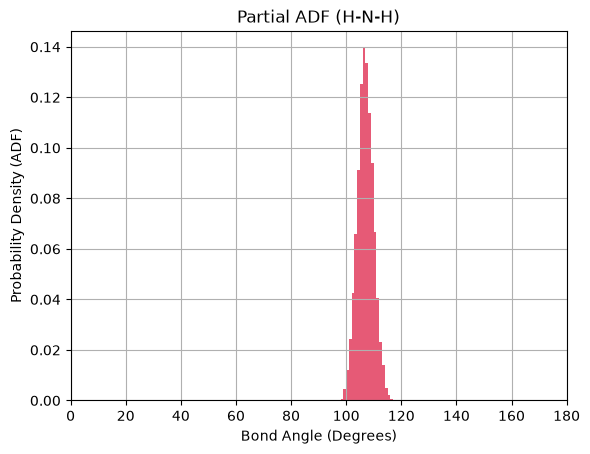

In [133]:

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

In [134]:
partial_adf_h_n_h = {
    "bin_centers": bin_centers,
    "probability_density": probability_density,
    "total_counts": total_counts,
    "bin_edges": bin_edges,
    "area_left": area_left,
    "area_right": area_right,
    "ratio": ratio,
    "valley_idx": valley_idx,
    "center_element": center_element,
    "neighbor_element": neighbor_element,
    "cutoff": cutoff,
    "bins": bins,
}

pickle_path = os.path.join(output_dir, "partial_adf_h_n_h.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(partial_adf_h_n_h , f)

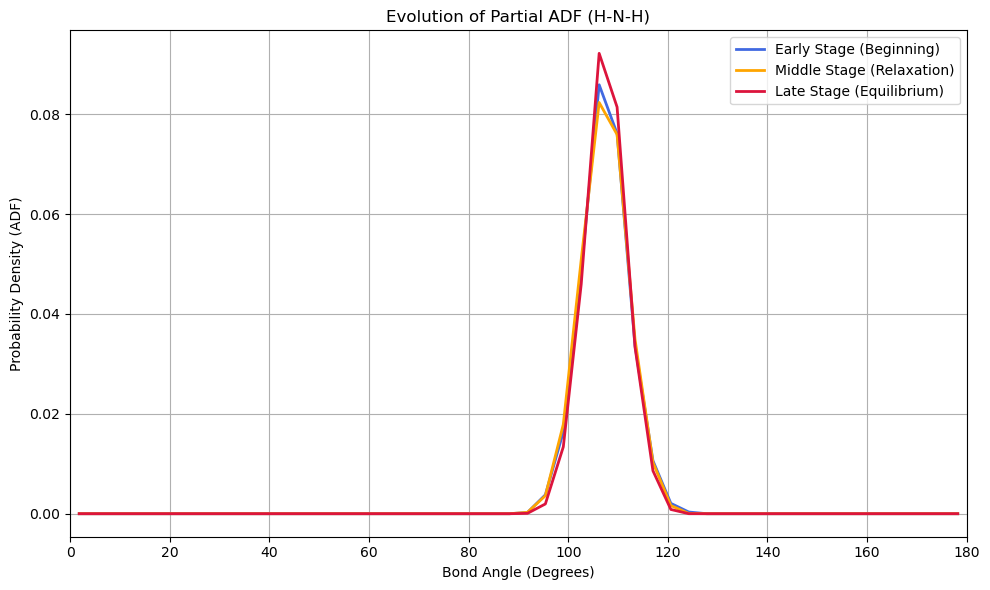

In [ ]:
cutoff = 1.5
center_element = 'N'
neighbor_element = 'H'
bins = 50
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

## OACF-based analysis

In [ ]:
# NOTE: for this section only, we used the very first data (5000 frames) that was provided to us.
# However, as the computation proved heavy but uninformative (OACF is almost constant), we decided not to repeat it with the new data.

(OACF - Orientational Autocorrelation Function)

It is a time-dependent statistical tool used to track how quickly molecules (or specific chemical bonds, functional groups, or dipole moments) rotate and change their spatial orientation over time due to thermal motion and local interactions.


Mathematically, it measures the correlation of a chosen unit vector $\hat{u}(t)$ describing a molecule's orientation at time $t$ with its initial orientation at an arbitrary starting time $t_0$. Most commonly, it is expressed using Legendre polynomials $P_n(x)$. The first-order ($n=1$) and second-order ($n=2$) OACFs are the most widely used:

$$C_1(t) = \langle \hat{u}(t_0) \cdot \hat{u}(t_0 + t) \rangle$$

$$C_2(t) = \langle P_2(\hat{u}(t_0) \cdot \hat{u}(t_0 + t)) \rangle = \frac{1}{2} \langle 3[\hat{u}(t_0) \cdot \hat{u}(t_0 + t)]^2 - 1 \rangle$$

Where the angular brackets $\langle \dots \rangle$ denote an ensemble average *over all molecules and time origins $t_0$* in your trajectory.


An OACF provides deep insight into the rotational dynamics and local environment of a system:

1. Extracting Rotational Relaxation Times: As time progresses, molecules collide and change directions, causing the correlation to decay toward zero. By fitting the OACF decay curve (often to an exponential or multi-exponential function like $e^{-t/\tau}$), it can be extracted the rotational correlation time ($\tau$). This tells you exactly how long it takes a molecule to lose memory of its initial orientation.

2. In a dense liquid or crowded environment: The OACF often exhibits a short-term oscillation or a slower, staggered decay. This reveals a "cage effect," where a molecule is trapped by its neighbors and bounces back and forth before successfully rotating.

3. Connecting Simulation to Spectroscopy Experiments: OACFs are the bridge between MD trajectories and actual physical laboratory measurements:$C_1(t)$ relates directly to Dielectric Relaxation spectroscopy and infrared (IR) absorption profiles, as it tracks the relaxation of total molecular dipole moments. $C_2(t)$ relates directly to Nuclear Magnetic Resonance (NMR) relaxation times ($T_1, T_2$), Raman scattering, and fluorescence anisotropy.

**In the program only C1 has been calculated.**

In the code, the orientation vectors (which represent the unit vectors $\hat{u}$) are calculated step-by-step through a combination of structural topology filtering, distance vector extraction, and normalization:

1. Identifying the Specific Molecular Bonds (pairs): Before calculating any vectors, the code needs to know which specific bonds it should track throughout the simulation. It does this by analyzing the very first frame (images[0]). It generates a neighbor list using a cutoff distance .It filters through all the neighboring atom pairs to find only the connections we need. The code assumes that these specific atoms stay bonded or associated in the same way across the entire simulation.

2. Extracting the Directional Vectors: Once the specific pairs are identified, the code loops through every single frame in MD trajectory and every identified molecular pair (m_idx).

3. Normalizing to Unit Vectors ($\hat{u}$): An OACF requires orientational vectors, meaning we only care about the direction the bond is pointing, not how long the bond is stretching or vibrating. To isolate just the direction, the code normalizes each raw displacement vector by dividing it by its own Euclidean length (norm)


In [ ]:
num_frames = len(images)

first_frame = images[0]
symbols = first_frame.get_chemical_symbols()
i, j = neighbor_list('ij', first_frame, cutoff=3.9, self_interaction=False)

pairs = []
for idx_i, idx_j in zip(i, j):
    if symbols[idx_i] == 'I' and symbols[idx_j] == 'Sn':
        pairs.append((idx_i, idx_j))

num_molecules = len(pairs)
vectors = np.zeros((num_frames, num_molecules, 3))

for f_idx, atoms in enumerate(images):
    for m_idx, (c_idx, n_idx) in enumerate(pairs):
        vec = atoms.get_distance(c_idx, n_idx, vector=True, mic=True)
        vectors[f_idx, m_idx] = vec / np.linalg.norm(vec)

oacf = np.zeros(num_frames)
for delta in range(num_frames):
    v_t = vectors[:num_frames - delta]
    v_tdelta = vectors[delta:]
    oacf[delta] = np.mean(np.sum(v_t * v_tdelta, axis=2))

time_axis = np.arange(num_frames)


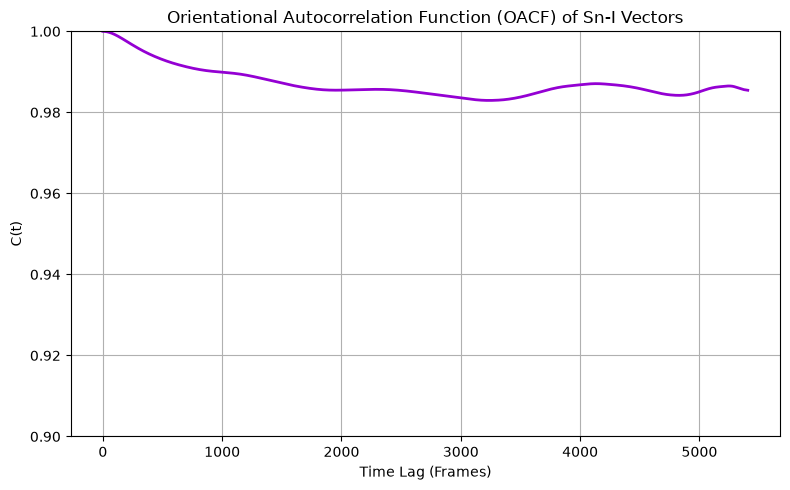

In [51]:

plt.figure(figsize=(8, 5))
plt.plot(time_axis, oacf, color='darkviolet', lw=2)
plt.xlabel('Time Lag (Frames)')
plt.ylabel('C(t)')
plt.title('Orientational Autocorrelation Function (OACF) of Sn-I Vectors')
plt.grid(True)
plt.ylim(0.9, 1.)
plt.tight_layout()
plt.show()

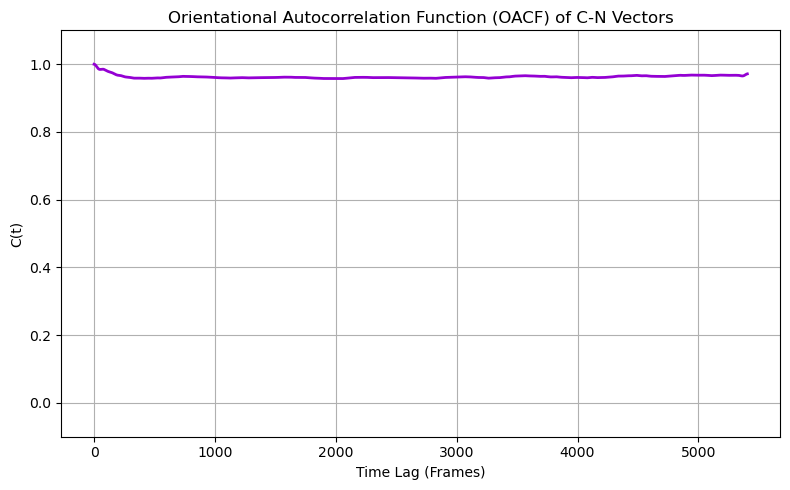

In [ ]:
first_frame = images[0]
symbols = first_frame.get_chemical_symbols()
i, j = neighbor_list('ij', first_frame, cutoff=1.6, self_interaction=False)

pairs = []
for idx_i, idx_j in zip(i, j):
    if symbols[idx_i] == 'C' and symbols[idx_j] == 'H':
        pairs.append((idx_i, idx_j))

num_molecules = len(pairs)
vectors = np.zeros((num_frames, num_molecules, 3))

for f_idx, atoms in enumerate(images):
    for m_idx, (c_idx, n_idx) in enumerate(pairs):
        vec = atoms.get_distance(c_idx, n_idx, vector=True, mic=True)
        vectors[f_idx, m_idx] = vec / np.linalg.norm(vec)

oacf = np.zeros(num_frames)
for delta in range(num_frames):
    v_t = vectors[:num_frames - delta]
    v_tdelta = vectors[delta:]
    oacf[delta] = np.mean(np.sum(v_t * v_tdelta, axis=2))

time_axis = np.arange(num_frames)


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(time_axis, oacf, color='darkviolet', lw=2)
plt.xlabel('Time Lag (Frames)')
plt.ylabel('C(t)')
plt.title('Orientational Autocorrelation Function (OACF) of C-H Vectors')
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

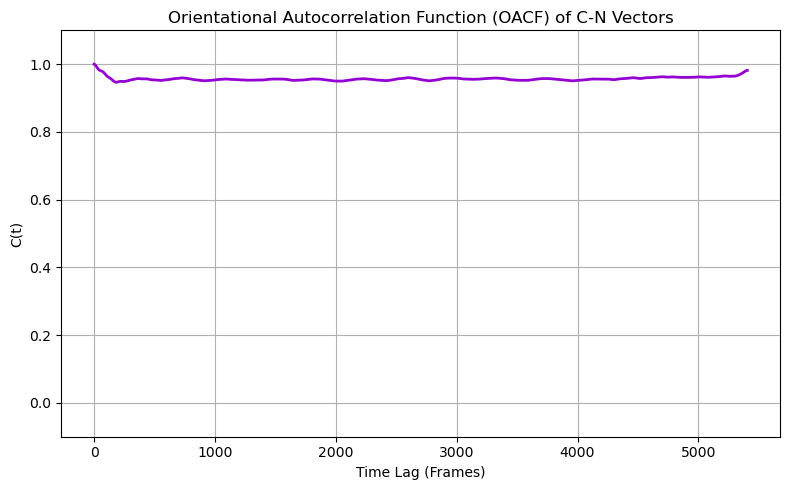

In [ ]:
first_frame = images[0]
symbols = first_frame.get_chemical_symbols()
i, j = neighbor_list('ij', first_frame, cutoff=1.6, self_interaction=False)

pairs = []
for idx_i, idx_j in zip(i, j):
    if symbols[idx_i] == 'H' and symbols[idx_j] == 'N':
        pairs.append((idx_i, idx_j))

num_molecules = len(pairs)
vectors = np.zeros((num_frames, num_molecules, 3))

for f_idx, atoms in enumerate(images):
    for m_idx, (c_idx, n_idx) in enumerate(pairs):
        vec = atoms.get_distance(c_idx, n_idx, vector=True, mic=True)
        vectors[f_idx, m_idx] = vec / np.linalg.norm(vec)

oacf = np.zeros(num_frames)
for delta in range(num_frames):
    v_t = vectors[:num_frames - delta]
    v_tdelta = vectors[delta:]
    oacf[delta] = np.mean(np.sum(v_t * v_tdelta, axis=2))

time_axis = np.arange(num_frames)


In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(time_axis, oacf, color='darkviolet', lw=2)
plt.xlabel('Time Lag (Frames)')
plt.ylabel('C(t)')
plt.title('Orientational Autocorrelation Function (OACF) of H-N Vectors')
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

## VDOS analysis (via FFT)


Vibrational Density of States (VDOS), denoted as $g(\omega)$ ,tells you the distribution of vibrational modes (or frequencies) available to a system of atoms. 

Is a sort of "fingerprint spectrum" of atomic motion: it counts how many vibrational frequencies exist within a specific frequency interval. If a system has a high VDOS at a particular frequency $\omega$, it means many atoms are collective-vibrating, rocking, or stretching at that exact rate.

In Molecular Dynamics , the most common way to calculate the VDOS is by **taking the Fourier Transform of the Velocity Autocorrelation Function (VACF) of the atoms**:

$$g(\omega) = \int_{0}^{\infty} \langle \vec{v}(t_0) \cdot \vec{v}(t_0 + t) \rangle \cos(\omega t) \, dt$$

Where $\langle \vec{v}(t_0) \cdot \vec{v}(t_0 + t) \rangle$ is the VACF, tracking how atoms lose memory of their initial velocities due to interatomic collisions and forces.




VDOS connects atomic-scale trajectories directly to macroscopic and experimental properties:

#### 1. Connecting to Experimental Spectroscopy
VDOS is the direct simulation counterpart to experimental Inelastic Neutron Scattering (INS), Infrared (IR), and Raman spectroscopy. Plotting the VDOS from an MD simulation, the peaks you see correspond directly to the vibrational absorption bands measured in a physical laboratory.

#### 2. Identifying Structural Phases and Rigidity
Crystalline solids will show sharp, well-defined peaks in the VDOS, corresponding to specific phonon modes (lattice vibrations).


#### 3. Calculating Thermodynamic Properties
We can bypass complex free-energy simulations to estimate quantum-corrected thermodynamic quantities. Under the harmonic approximation, we can integrate the VDOS to compute:
* Vibrational Entropy ($S_{\text{vib}}$)
* Constant-volume Heat Capacity ($C_v$)
* Zero-point energy (ZPE)

#### 4. Uncovering Atomic-Scale Mechanisms
By computing the partial or projected VDOS (filtering the velocity vectors for only specific atom types), we can figure out exactly which atoms are responsible for which vibrational peaks. 

In the program:

Instead of calculating the Velocity Autocorrelation Function (VACF) in the time domain first, this script utilizes a numerical shortcut known as the **Wiener-Khinchin theorem**. This theorem proves that the power spectrum of a signal's Fourier Transform is mathematically identical to the Fourier Transform of its autocorrelation function. 


* 1. Approximating Velocities from Positions
Since raw `.extxyz` trajectory files often contain only atomic coordinates, the script first calculates the velocities using numerical differentiation

* 2. Setting Up the Frequency Domain: To map the final spectrum onto actual physical units, the code defines the frequency axis based on the total number of velocity frames and the real-time spacing between them, Using rfftfreq

* 3. The Fast Fourier Transform (FFT) and Power Spectrum: For the isolated velocities of a given element, the code shifts the entire trajectory from the time domain to the frequency domain using a Real Fast Fourier Transform along the time axis (axis=0).
Immediately after, it computes the Power Spectrum by squaring the absolute magnitude of the complex Fourier coefficients.
The power_spectrum array contains data partitioned by frames, atoms, and spatial coordinates (X, Y, Z). To get a single, scalar intensity value for each frequency.
* 4. Compiling the Total VDOS : the script sums over all atoms of that element and all three spatial dimensions


In [111]:
# in INCAR POTIM=0.5 ---> time step is 0.5 femtoseconds 

In [135]:
timestep = 0.5

first_frame = images_equilibrium[0]
symbols = np.array(first_frame.get_chemical_symbols())
unique_elements = sorted(list(set(symbols)))

cell = first_frame.get_cell()
pbc = first_frame.get_pbc()

all_velocities = []
prev_pos = images_equilibrium[0].get_positions()
for atoms in images_equilibrium[1:]:
    pos = atoms.get_positions()
    step_disp = pos - prev_pos
    step_disp, _ = find_mic(step_disp, cell, pbc=pbc)
    all_velocities.append(step_disp / timestep)
    prev_pos = pos

all_velocities = np.array(all_velocities)
num_frames = len(all_velocities)
frequencies = np.fft.rfftfreq(num_frames, d=timestep)

print("Max v dataset:", np.max(np.abs(all_velocities)))

vdos_data = {}
total_vdos = np.zeros(len(frequencies))

for element in unique_elements:
    mask = (symbols == element)
    element_velocities = all_velocities[:, mask, :]

    fft_v = np.fft.rfft(element_velocities, axis=0)
    power_spectrum = np.abs(fft_v) ** 2
    pvdos = np.sum(power_spectrum, axis=(1, 2))

    vdos_data[element] = pvdos
    total_vdos += pvdos

Max v dataset: 0.04147999999999996


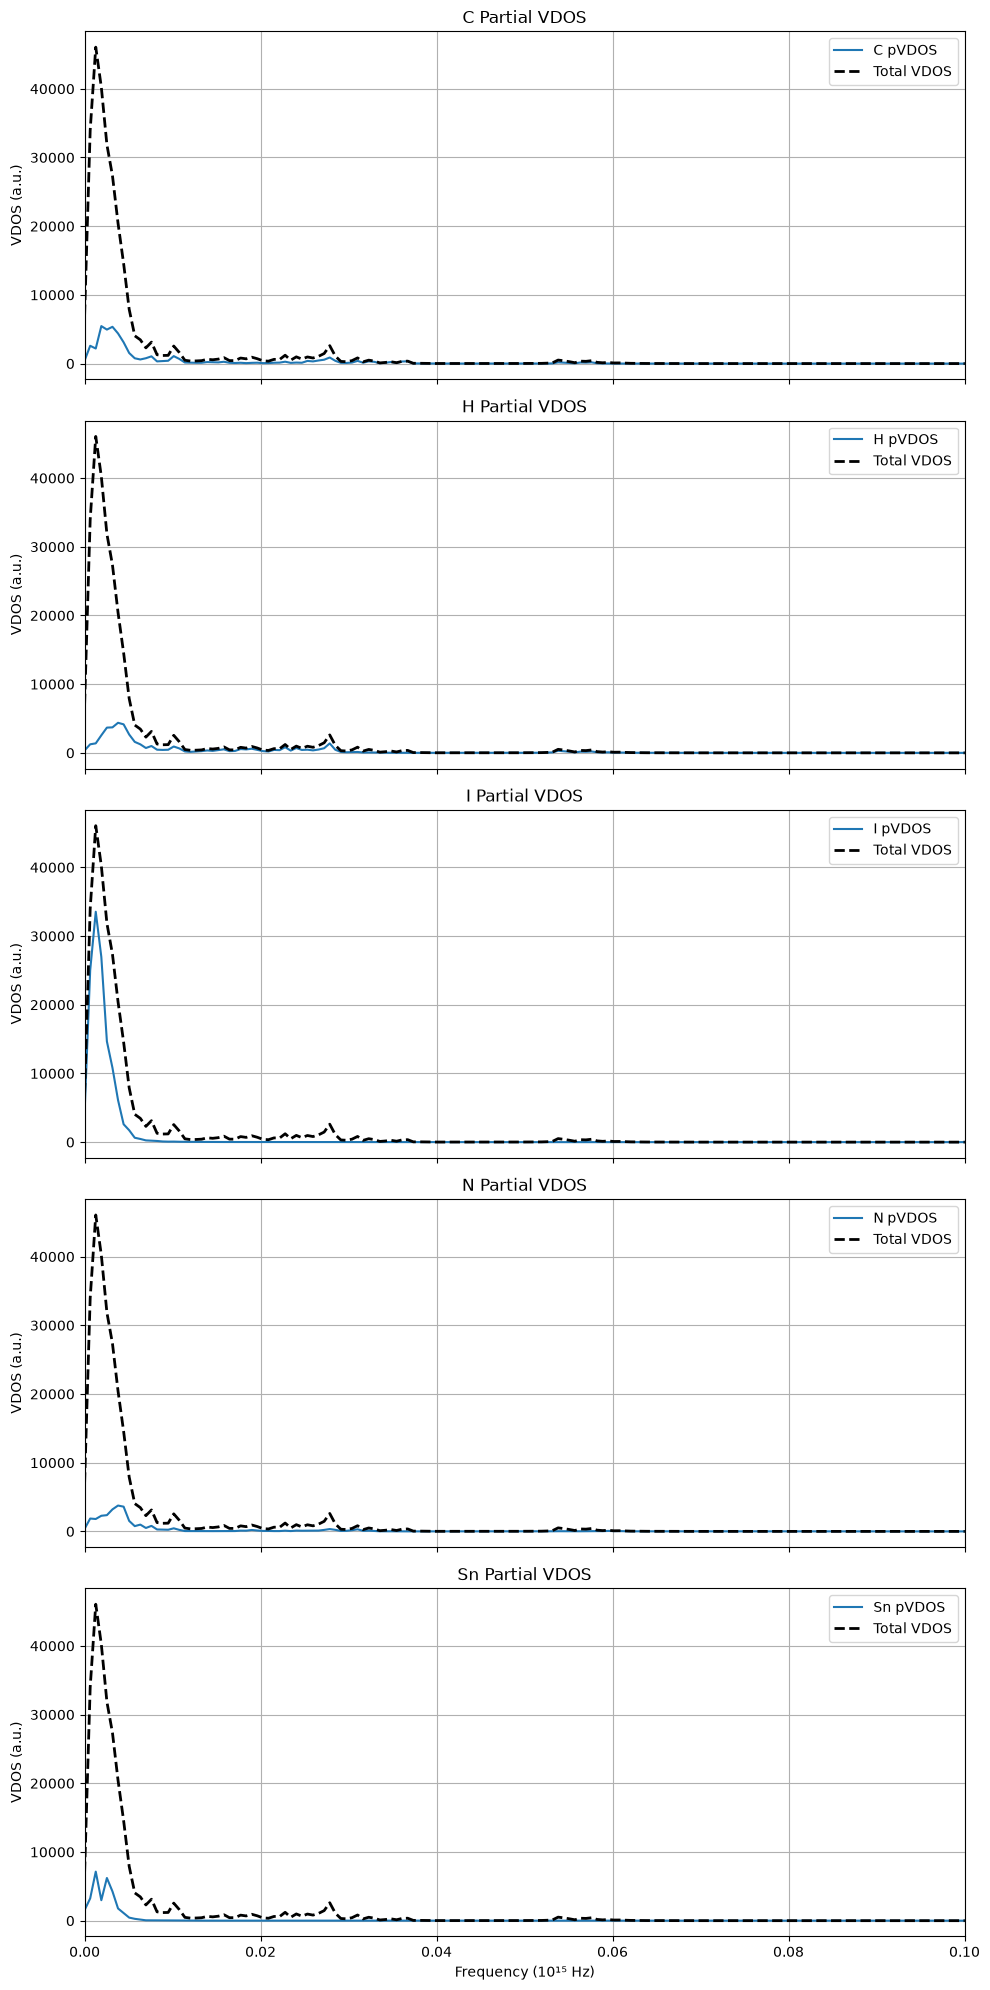

In [144]:
n_elements = len(unique_elements)
fig, axes = plt.subplots(n_elements, 1, figsize=(10, 4*n_elements), sharex=True)
if n_elements == 1:
    axes = [axes]

for ax, (element, pvdos) in zip(axes, vdos_data.items()):
    ax.plot(frequencies, pvdos, label=f'{element} pVDOS', lw=1.5)
    ax.plot(frequencies, total_vdos, label='Total VDOS', color='black', lw=2, linestyle='--')
    ax.set_ylabel('VDOS (a.u.)')
    ax.set_title(f'{element} Partial VDOS')
    ax.set_xlim(frequencies[0], 0.1)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel('Frequency (10¹⁵ Hz)') 
plt.tight_layout()
plt.show()

In [138]:
vdos_analysis = {
    "frequencies": frequencies,
    "total_vdos": total_vdos,
    "vdos_data": vdos_data,
    "unique_elements": unique_elements,
}
pickle_path = os.path.join(output_dir, "vdos_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(vdos_analysis, f)

In [139]:
timestep = 0.5

first_frame = images_equilibrium[0]
symbols = np.array(first_frame.get_chemical_symbols())
masses = first_frame.get_masses()
unique_elements = sorted(list(set(symbols)))

cell = first_frame.get_cell()
pbc = first_frame.get_pbc()

all_velocities = []
prev_pos = images_equilibrium[0].get_positions()
for atoms in images_equilibrium[1:]:
    pos = atoms.get_positions()
    step_disp = pos - prev_pos
    step_disp, _ = find_mic(step_disp, cell, pbc=pbc)
    all_velocities.append(step_disp / timestep)
    prev_pos = pos

all_velocities = np.array(all_velocities)
num_frames = len(all_velocities)
frequencies = np.fft.rfftfreq(num_frames, d=timestep)

vdos_data = {}
total_vdos = np.zeros(len(frequencies))

for element in unique_elements:
    mask = (symbols == element)
    element_velocities = all_velocities[:, mask, :]
    element_mass = masses[mask][0]

    fft_v = np.fft.rfft(element_velocities, axis=0)
    power_spectrum = np.abs(fft_v) ** 2
    pvdos = np.sum(power_spectrum, axis=(1, 2)) * element_mass

    vdos_data[element] = pvdos
    total_vdos += pvdos


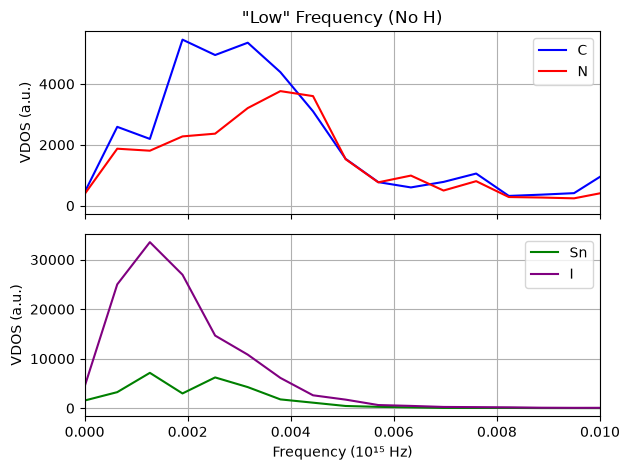

In [145]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
colors = {'C': 'blue', 'N': 'red', 'Sn': 'green', 'I': 'purple'}

# Top: C, N
for element in ['C', 'N']:
    if element in vdos_data:
        ax1.plot(frequencies, vdos_data[element], label=f'{element}', lw=1.5, color=colors[element])
ax1.set_ylabel('VDOS (a.u.)')
ax1.set_title('"Low" Frequency (No H)')
ax1.legend()
ax1.grid(True)

# Bottom: Sn, I
for element in ['Sn', 'I']:
    if element in vdos_data:
        ax2.plot(frequencies, vdos_data[element], label=f'{element}', lw=1.5, color=colors[element])
ax2.set_xlabel('Frequency (10¹⁵ Hz)')
ax2.set_ylabel('VDOS (a.u.)')
ax2.legend()
ax2.grid(True)

ax2.set_xlim([0., 0.01])
plt.tight_layout()
plt.show()

In [141]:
low_freq_vdos_analysis = {
    "frequencies": frequencies,
    "vdos_data": {k: v for k, v in vdos_data.items() if k in ['C', 'N', 'Sn', 'I']},
    "colors": colors,
}
pickle_path = os.path.join(output_dir, "low_freq_vdos_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(low_freq_vdos_analysis, f)

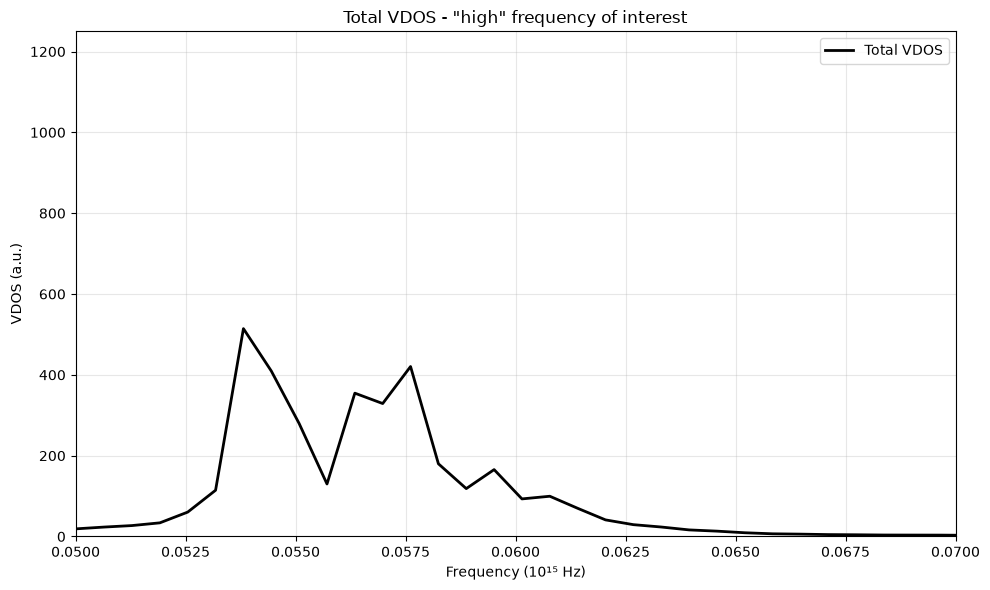

In [ ]:
# --- Plot total VDOS in a specific (visually identified) frequency range ---
plt.figure(figsize=(10, 6))

# Plot total VDOS
plt.plot(frequencies, total_vdos, color='black', lw=2, label='Total VDOS')

# Set x-axis limits to the desired range (0.05 to 0.07 in 10^15 Hz)
plt.xlim(0.05, 0.07)
plt.ylim([0., 1250])

plt.xlabel('Frequency (10¹⁵ Hz)')
plt.ylabel('VDOS (a.u.)')
plt.title('Total VDOS - "high" frequency of interest')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Theoretical expected peaks (order of magnitude) for a hybrid perovskite (source: various papers):
* inorganic 10^(-3) THz -> ok
* organic 10^(-3) THz but higher than inorganic; -> ok
* organic + inorganic: 10^(-3) to 10^(-2) THz; -> ok (see total VDOS)
* organic (cations): 10^(-2) THz -> ok (see especially C, H)
* organic, C-H and N-H: around 9 * 10^(-2) THz (see total in interval above, completely due to H)

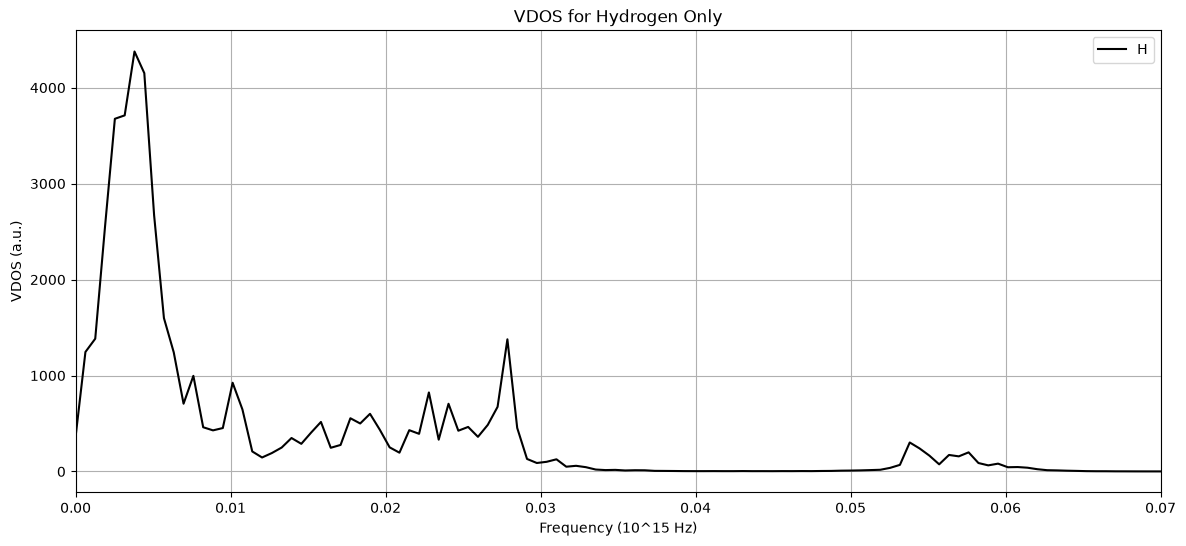

In [ ]:
plt.figure(figsize=(14,6))
if 'H' in vdos_data:
    plt.plot(frequencies, vdos_data['H'], label='H', lw=1.5, color='black')

plt.xlim([0.,0.07])
plt.xlabel('Frequency (10^15 Hz)')
plt.ylabel('VDOS (a.u.)')
plt.title('VDOS for Hydrogen Only')
plt.legend()
plt.grid(True)

plt.show()

In [146]:
hydrogen_vdos_analysis = {
    "frequencies": frequencies,
    "vdos_H": vdos_data.get('H', None),
}
pickle_path = os.path.join(output_dir, "hydrogen_vdos_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(hydrogen_vdos_analysis, f)

## MSD analysis

(Mean squared displacement)

In [ ]:
ORGANIC_SYMBOLS = {"H", "C", "N"}
INORGANIC_SYMBOLS = {"Sn", "I"}

input_file = my_equilibrium_file

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found.")
    exit(1)

times = []
msd_full = []
msd_org = []
msd_inorg = []
msd_h = []

rmsd_full = []
rmsd_org = []
rmsd_inorg = []
rmsd_h = []

ref_pos_full = None
ref_pos_org = None
ref_pos_inorg = None
ref_pos_h = None

for index, atoms in enumerate(iread(input_file, index=":")):
    times.append(index)
    
    #splitting indexes
    org_indices = [atom.index for atom in atoms if atom.symbol in ORGANIC_SYMBOLS]
    inorg_indices = [atom.index for atom in atoms if atom.symbol in INORGANIC_SYMBOLS]
    h_indices = [atom.index for atom in atoms if atom.symbol == "H"]
    
    #taking position
    pos_full = atoms.get_positions()
    pos_org = pos_full[org_indices] if org_indices else np.array([])
    pos_inorg = pos_full[inorg_indices] if inorg_indices else np.array([])
    pos_h = pos_full[h_indices] if h_indices else np.array([])
    
    #starting point
    if index == 0:
        ref_pos_full = pos_full.copy()
        ref_pos_org = pos_org.copy() if pos_org.size > 0 else None
        ref_pos_inorg = pos_inorg.copy() if pos_inorg.size > 0 else None
        ref_pos_h = pos_h.copy() if pos_h.size > 0 else None

# unwrapped position accumulators, initialized at frame 0
    if index == 0:
        prev_pos_full = pos_full.copy()
        unwrapped_pos_full = pos_full.copy()
    else:
        step_disp = pos_full - prev_pos_full
        step_disp, _ = find_mic(step_disp, atoms.get_cell(), pbc=atoms.get_pbc())
        unwrapped_pos_full += step_disp
        prev_pos_full = pos_full.copy()
    unwrapped_pos_org = unwrapped_pos_full[org_indices] if org_indices else np.array([])
    unwrapped_pos_inorg = unwrapped_pos_full[inorg_indices] if inorg_indices else np.array([])
    unwrapped_pos_h = unwrapped_pos_full[h_indices] if h_indices else np.array([])

    sq_dist_full = np.sum((unwrapped_pos_full - ref_pos_full) ** 2, axis=1)

    msd_full.append(np.mean(sq_dist_full))
    
    if ref_pos_org is not None and pos_org.size > 0:
        sq_dist_org = np.sum((unwrapped_pos_org - ref_pos_org) ** 2, axis=1) 
        msd_org.append(np.mean(sq_dist_org))
    else:
        msd_org.append(0.0)
        
    if ref_pos_inorg is not None and pos_inorg.size > 0:
        sq_dist_inorg = np.sum((unwrapped_pos_inorg - ref_pos_inorg) ** 2, axis=1)
        msd_inorg.append(np.mean(sq_dist_inorg))
    else:
        msd_inorg.append(0.0)

    if ref_pos_h is not None and pos_h.size > 0:
        sq_dist_h = np.sum((unwrapped_pos_h - ref_pos_h) ** 2, axis=1) 
        msd_h.append(np.mean(sq_dist_h))
    else:
        msd_h.append(0.0)

    #root mean squared deviation
    rmsd_full.append(np.sqrt(np.mean(sq_dist_full)))
    
    if ref_pos_org is not None and pos_org.size > 0:
        rmsd_org.append(np.sqrt(np.mean(sq_dist_org)))
    else:
        rmsd_org.append(0.0)
        
    if ref_pos_inorg is not None and pos_inorg.size > 0:
        rmsd_inorg.append(np.sqrt(np.mean(sq_dist_inorg)))
    else:
        rmsd_inorg.append(0.0)

    if ref_pos_h is not None and pos_h.size > 0:
        rmsd_h.append(np.sqrt(np.mean(sq_dist_h)))
    else:
        rmsd_h.append(0.0)

print(f"Processed {len(times)} frames successfully.")

#saving result
times = np.array(times)
msd_full = np.array(msd_full)
msd_org = np.array(msd_org)
msd_inorg = np.array(msd_inorg)
msd_h = np.array(msd_h)

rmsd_full = np.array(rmsd_full)
rmsd_org = np.array(rmsd_org)
rmsd_inorg = np.array(rmsd_inorg)
rmsd_h = np.array(rmsd_h)


Processed 3160 frames successfully.


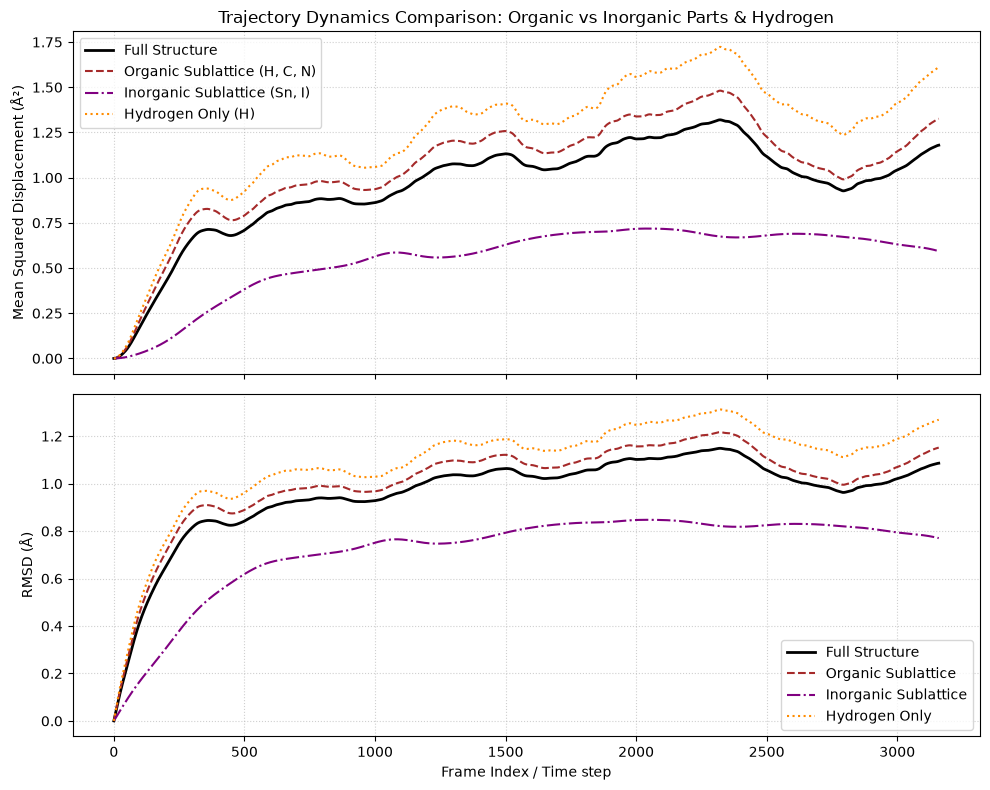

In [149]:
#plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: MSD
ax1.plot(times, msd_full, label="Full Structure", color="black", linewidth=2)
ax1.plot(times, msd_org, label="Organic Sublattice (H, C, N)", color="brown", linestyle="--")
ax1.plot(times, msd_inorg, label="Inorganic Sublattice (Sn, I)", color="purple", linestyle="-.")
ax1.plot(times, msd_h, label="Hydrogen Only (H)", color="darkorange", linestyle=":")
ax1.set_ylabel("Mean Squared Displacement (Å²)")
ax1.set_title("Trajectory Dynamics Comparison: Organic vs Inorganic Parts & Hydrogen")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Bottom Plot: RMSD
ax2.plot(times, rmsd_full, label="Full Structure", color="black", linewidth=2)
ax2.plot(times, rmsd_org, label="Organic Sublattice", color="brown", linestyle="--")
ax2.plot(times, rmsd_inorg, label="Inorganic Sublattice", color="purple", linestyle="-.")
ax2.plot(times, rmsd_h, label="Hydrogen Only", color="darkorange", linestyle=":")
ax2.set_ylabel("RMSD (Å)")
ax2.set_xlabel("Frame Index / Time step")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
#plt.savefig("trajectory_dynamics_comparison.png", dpi=300)
#print("Comparison plot saved as 'trajectory_dynamics_comparison.png'")
plt.show()

In [151]:
msd_rmsd_analysis = {
    "times": times,
    "msd_full": msd_full,
    "msd_org": msd_org,
    "msd_inorg": msd_inorg,
    "msd_h": msd_h,
    "rmsd_full": rmsd_full,
    "rmsd_org": rmsd_org,
    "rmsd_inorg": rmsd_inorg,
    "rmsd_h": rmsd_h,
}
pickle_path = os.path.join(output_dir, "msd_rmsd_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(msd_rmsd_analysis, f)

In [150]:
# ------------------------------------------------------------
# 2. Initialise dictionaries
# ------------------------------------------------------------
times = []
msd_elements = {}
rmsd_elements = {}
ref_positions = {}          # initial unwrapped positions per element
prev_pos_full = None        # for frame‑to‑frame displacement
unwrapped_pos_full = None   # cumulative unwrapped positions

# ------------------------------------------------------------
# 3. Loop over frames
# ------------------------------------------------------------
for index, atoms in enumerate(iread(input_file, index=":")):
    times.append(index)

    # Current wrapped positions and symbols
    pos_full = atoms.get_positions()
    symbols = np.array(atoms.get_chemical_symbols())
    unique_elements = sorted(set(symbols))

    # ---- First frame: set up references ----
    if index == 0:
        # Initialise dictionaries for all elements
        for element in unique_elements:
            msd_elements[element] = []
            rmsd_elements[element] = []
        # Set reference positions (will be overwritten after unwrapping)
        # We will set them after unwrapping the first frame

        # Initialise unwrapping
        prev_pos_full = pos_full.copy()
        unwrapped_pos_full = pos_full.copy()   # at frame 0, unwrapped = wrapped

        # Now store reference positions for each element from the unwrapped frame 0
        for element in unique_elements:
            mask = (symbols == element)
            ref_positions[element] = unwrapped_pos_full[mask].copy()

    else:
        # ---- Compute frame‑to‑frame displacement with MIC ----
        step_disp = pos_full - prev_pos_full
        step_disp, _ = find_mic(step_disp, atoms.get_cell(), pbc=atoms.get_pbc())
        unwrapped_pos_full += step_disp
        prev_pos_full = pos_full.copy()

    # ---- For each element, compute MSD/RMSD from unwrapped positions ----
    for element in unique_elements:
        mask = (symbols == element)
        if np.any(mask):
            # Unwrapped positions for this element
            unwrapped_pos_element = unwrapped_pos_full[mask]
            # Reference positions (initial unwrapped)
            ref_pos_element = ref_positions[element]

            # Squared displacements
            sq_dist = np.sum((unwrapped_pos_element - ref_pos_element) ** 2, axis=1)
            mean_sq_dist = np.mean(sq_dist)

            msd_elements[element].append(mean_sq_dist)
            rmsd_elements[element].append(np.sqrt(mean_sq_dist))
        else:
            # Should not happen because we only loop over elements present
            msd_elements[element].append(0.0)
            rmsd_elements[element].append(0.0)

# ------------------------------------------------------------
# 4. Convert to numpy arrays for plotting
# ------------------------------------------------------------
times = np.array(times)
for element in msd_elements:
    msd_elements[element] = np.array(msd_elements[element])
    rmsd_elements[element] = np.array(rmsd_elements[element])

print(f"Processed {len(times)} frames successfully. Elements: {list(msd_elements.keys())}")
 

Processed 3160 frames successfully. Elements: [np.str_('C'), np.str_('H'), np.str_('I'), np.str_('N'), np.str_('Sn')]


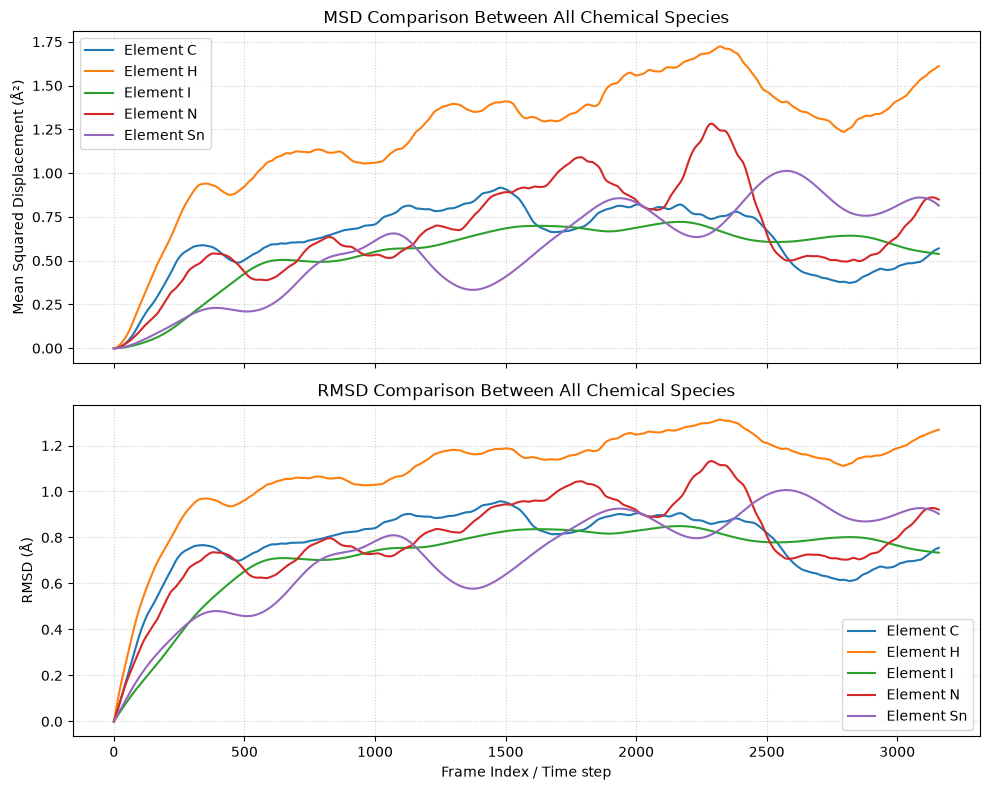

In [152]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for element in msd_elements.keys():
    ax1.plot(times, msd_elements[element], label=f"Element {element}", linewidth=1.5)
    ax2.plot(times, rmsd_elements[element], label=f"Element {element}", linewidth=1.5)

ax1.set_ylabel("Mean Squared Displacement (Å²)")
ax1.set_title("MSD Comparison Between All Chemical Species")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.set_ylabel("RMSD (Å)")
ax2.set_xlabel("Frame Index / Time step")
ax2.set_title("RMSD Comparison Between All Chemical Species")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
#plt.savefig("element_dynamics_comparison.png", dpi=300)
#print("Comparison plot saved as 'element_dynamics_comparison.png'")
plt.show()

In [153]:
element_msd_rmsd_analysis = {
    "times": times,
    "msd_elements": msd_elements,
    "rmsd_elements": rmsd_elements,
    "unique_elements": list(msd_elements.keys()),
}
pickle_path = os.path.join(output_dir, "element_msd_rmsd_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(element_msd_rmsd_analysis, f)

## Temperature cross-check

$$T = \frac{2 \cdot E_k}{3 \cdot N \cdot k_B}$$

### Calculating Instantaneous Temperature from Trajectory Positions

* Numerical Velocity Extraction with Periodic Boundary Conditions (PBC): Since raw trajectory files (like .extxyz) typically only contain atomic coordinates, velocities (as before) must be reconstructed using finite differences ($\Delta v = \Delta x / \Delta t$)

* Displacement Calculation: For each consecutive frame, the script calculates the displacement vector ($\Delta p$) for every atom. Minimum Image Convention (MIC): If an atom crosses a periodic boundary between two frames, a naive subtraction would yield a massive, artificial displacement vector stretching across the entire simulation box. The function find_mic() wraps the displacement back into the box, ensuring we get the true, shortest physical distance traveled by the atom.

* Computing the Total Kinetic Energy ($E_k$): Using the converted velocities and atomic masses, the script computes the instantaneous kinetic energy of the system for each frame

* Applying the Equipartition Theorem for Temperature:  According to the Equipartition Theorem, the total kinetic energy of a classical system at thermal equilibrium is directly proportional to its temperature and its degrees of freedom (DOF)

* Computing Corrected DoF and Instantaneous Temperature: the script calculates the proper degrees of freedom:$$N_{\text{dof}} = 3 N_{\text{moving}} - 3$$It then loops back through the trajectory frames, computes the total instantaneous kinetic energy ($E_k$), and applies the Equipartition Theorem to calculate the final mean temperature in Kelvin.



In [ ]:
timestep_in_fs = 0.5  

all_velocities = []
for i in range(len(images_equilibrium) - 1):
    delta_p = images_equilibrium[i+1].get_positions() - images_equilibrium[i].get_positions()
    delta_p, _ = find_mic(delta_p, images_equilibrium[i].get_cell(), pbc=images_equilibrium[i].get_pbc())
    all_velocities.append(delta_p / timestep_in_fs)

all_velocities = np.array(all_velocities)
N_atoms = len(images_equilibrium[0])
dynamic_dof = 3 * N_atoms - 3
temperatures = []

for i, atoms in enumerate(images_equilibrium[:-1]):
    masses = atoms.get_masses()
    v_ase = all_velocities[i] / units.fs
    ek = 0.5 * np.sum(masses[:, np.newaxis] * (v_ase ** 2))
    t_instantaneous = (2 * ek) / (dynamic_dof * units.kB)
    temperatures.append(t_instantaneous)

mean_temperature = np.mean(temperatures)
print(f"Calculated mean temperature: {mean_temperature:.2f} K")

Calculated mean temperature: 224.75 K


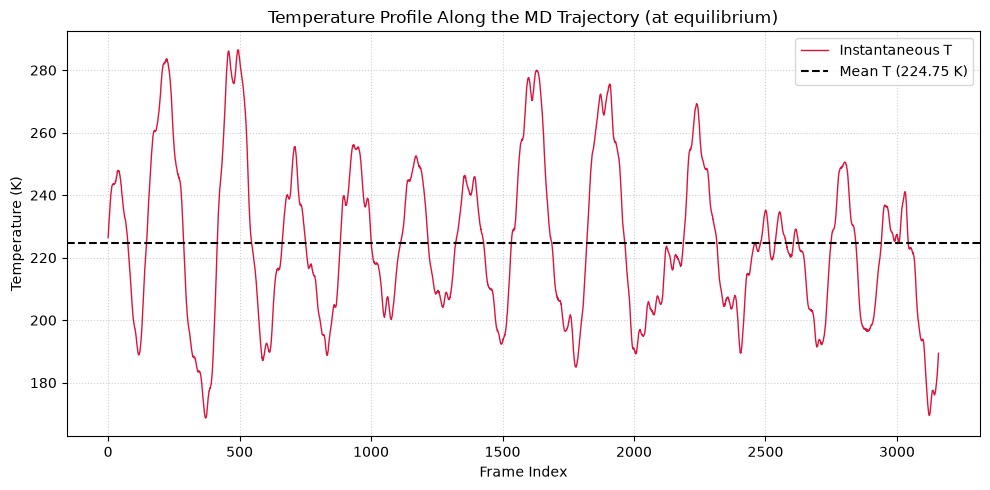

In [157]:
time_steps = np.arange(len(temperatures))

plt.figure(figsize=(10, 5))
plt.plot(time_steps, temperatures, color="crimson", linewidth=1, label="Instantaneous T")
plt.axhline(y=mean_temperature, color="black", linestyle="--", linewidth=1.5, label=f"Mean T ({mean_temperature:.2f} K)")

plt.xlabel("Frame Index")
plt.ylabel("Temperature (K)")
plt.title("Temperature Profile Along the MD Trajectory (at equilibrium)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

plt.show()

In [159]:
temperature_equilibrium_analysis = {
    "time_steps": time_steps,
    "temperatures": temperatures,
    "mean_temperature": mean_temperature,
}
pickle_path = os.path.join(output_dir, "temperature_equilibrium_analysis.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(temperature_equilibrium_analysis, f)

In [158]:
! echo "Actual simulation temperature (K):" && cat $INCAR_FILE | grep "TEBEG" 

Actual simulation temperature (K):
TEBEG = 300


Temperature is more or less 50 degrees smaller than temperature from outcar

In [ ]:
# NOTE: lower result than the expected 300 K is probably due to finite-difference calculation artifact (ie, H oscillates too fast for its full 
# movement to be seen in the 15 fs timestep; see 'Temperature' section in 'Convergence check' part for more details)

In [ ]:
# note: formula for DOFs justified bc: remove 3 dofs bc translation of center of mass